# EDA: YouTube-каналы об истории (ВОВ / Вторая мировая)

**Цель:** Провести разведочный анализ данных YouTube-каналов, посвящённых историческим событиям и личностям Второй мировой войны.

**Задачи:**
1. Оценить качество и полноту данных
2. Сформировать пул репрезентативных каналов
3. Построить графики комментариев по годам (общие + по темам)
4. Классифицировать каналы по степени фокуса на истории
5. Оценить репрезентативность данных по каждому каналу

**Данные:** 12 тематических датасетов (события, личности, широкие запросы), ~412K видео, ~6.9M комментариев

---
## 0. Настройка окружения

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATA_ROOT = Path(r'data')

DATASETS = {
    'berlin':       {'path': 'events/berlin',       'group': 'events', 'label': 'Берлин'},
    'kursk':        {'path': 'events/kursk',        'group': 'events', 'label': 'Курск'},
    'leningrad':    {'path': 'events/leningrad',    'group': 'events', 'label': 'Ленинград'},
    'moscow':       {'path': 'events/moscow',       'group': 'events', 'label': 'Москва'},
    'stalingrad':   {'path': 'events/stalingrad',   'group': 'events', 'label': 'Сталинград'},
    'matros':       {'path': 'person/matros',       'group': 'person', 'label': 'Матросов'},
    'rokossovsky':  {'path': 'person/rokossovsky',  'group': 'person', 'label': 'Рокоссовский'},
    'stalin':       {'path': 'person/stalin',       'group': 'person', 'label': 'Сталин'},
    'zhukov':       {'path': 'person/zhukov',       'group': 'person', 'label': 'Жуков'},
    'zoya':         {'path': 'person/zoya',         'group': 'person', 'label': 'Зоя'},
    'gpw':          {'path': 'gpw',                 'group': 'broad',  'label': 'ВОВ'},
    'ww':           {'path': 'ww',                  'group': 'broad',  'label': 'Мировая война'},
}

GROUP_LABELS = {'events': 'События', 'person': 'Личности', 'broad': 'Широкие запросы'}

# YouTube category ID -> name
YT_CATEGORIES = {
    1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music',
    15: 'Pets & Animals', 17: 'Sports', 18: 'Short Movies',
    19: 'Travel & Events', 20: 'Gaming', 22: 'People & Blogs',
    23: 'Comedy', 24: 'Entertainment', 25: 'News & Politics',
    26: 'Howto & Style', 27: 'Education', 28: 'Science & Tech',
    29: 'Nonprofits & Activism', 43: 'Shows',
}

print('Setup complete')

Setup complete


---
## 1. Загрузка и объединение данных

In [46]:
def load_dataset(name, info):
    """Load videos, comments, channels for one dataset."""
    base = DATA_ROOT / info['path']
    
    # Videos
    vf = base / f'data_videos_{name}.csv'
    videos = pd.read_csv(vf, index_col=0, on_bad_lines='warn')
    videos['publish_date'] = pd.to_datetime(videos['publish_date'], errors='coerce')
    videos['dataset'] = name
    videos['group'] = info['group']
    videos['label'] = info['label']
    
    # Comments
    cf = base / f'data_comments_{name}.csv'
    comments = pd.read_csv(cf, index_col=0, on_bad_lines='warn')
    comments['comment_publish_date'] = pd.to_datetime(comments['comment_publish_date'], errors='coerce')
    comments['dataset'] = name
    comments['group'] = info['group']
    comments['label'] = info['label']
    
    # Channels (handle dis_channels_ vs data_channels_ naming)
    ch_files = list(base.glob('*channels_*.csv'))
    if not ch_files:
        raise FileNotFoundError(f'No channel file found in {base}')
    channels = pd.read_csv(ch_files[0], index_col=0, on_bad_lines='warn')
    channels['account_creation_date'] = pd.to_datetime(channels['account_creation_date'], errors='coerce')
    channels['dataset'] = name
    channels['group'] = info['group']
    channels['label'] = info['label']
    
    return videos, comments, channels

all_videos_list = []
all_comments_list = []
all_channels_list = []

for name, info in DATASETS.items():
    print(f'Loading {name}...')
    v, c, ch = load_dataset(name, info)
    all_videos_list.append(v)
    all_comments_list.append(c)
    all_channels_list.append(ch)
    print(f'  Videos: {len(v):,}  Comments: {len(c):,}  Channels: {len(ch):,}')

all_videos = pd.concat(all_videos_list, ignore_index=True)
all_comments = pd.concat(all_comments_list, ignore_index=True)
all_channels_raw = pd.concat(all_channels_list, ignore_index=True)

print(f'\nTotal: {len(all_videos):,} video records, {len(all_comments):,} comment records, {len(all_channels_raw):,} channel records')

Loading berlin...
  Videos: 404  Comments: 62,780  Channels: 354
Loading kursk...
  Videos: 1,306  Comments: 67,916  Channels: 1,024
Loading leningrad...
  Videos: 4,581  Comments: 135,853  Channels: 3,137
Loading moscow...
  Videos: 1,303  Comments: 114,312  Channels: 2,631
Loading stalingrad...
  Videos: 3,529  Comments: 154,211  Channels: 2,149
Loading matros...
  Videos: 152  Comments: 1,361  Channels: 106
Loading rokossovsky...
  Videos: 116  Comments: 11,180  Channels: 103
Loading stalin...
  Videos: 6,682  Comments: 803,332  Channels: 4,079
Loading zhukov...
  Videos: 1,045  Comments: 101,550  Channels: 718
Loading zoya...
  Videos: 342  Comments: 130,692  Channels: 604
Loading gpw...
  Videos: 18,806  Comments: 1,251,680  Channels: 9,262
Loading ww...
  Videos: 12,733  Comments: 1,990,749  Channels: 9,957

Total: 50,999 video records, 4,825,616 comment records, 34,124 channel records


In [47]:
# Summary table
summary_rows = []
for name, info in DATASETS.items():
    nv = len(all_videos[all_videos['dataset'] == name])
    nc = len(all_comments[all_comments['dataset'] == name])
    nch = len(all_channels_raw[all_channels_raw['dataset'] == name])
    summary_rows.append({'Dataset': name, 'Label': info['label'], 'Group': GROUP_LABELS[info['group']],
                         'Videos': nv, 'Comments': nc, 'Channels': nch})

summary_df = pd.DataFrame(summary_rows)
summary_df.loc[len(summary_df)] = ['TOTAL', '', '', summary_df['Videos'].sum(),
                                    summary_df['Comments'].sum(), summary_df['Channels'].sum()]
summary_df.style.format({'Videos': '{:,.0f}', 'Comments': '{:,.0f}', 'Channels': '{:,.0f}'})

,Dataset,Label,Group,Videos,Comments,Channels
0,berlin,Берлин,События,404,"62,780",354
1,kursk,Курск,События,"1,306","67,916","1,024"
2,leningrad,Ленинград,События,"4,581","135,853","3,137"
3,moscow,Москва,События,"1,303","114,312","2,631"
4,stalingrad,Сталинград,События,"3,529","154,211","2,149"
5,matros,Матросов,Личности,152,"1,361",106
6,rokossovsky,Рокоссовский,Личности,116,"11,180",103
7,stalin,Сталин,Личности,"6,682","803,332","4,079"
8,zhukov,Жуков,Личности,"1,045","101,550",718
9,zoya,Зоя,Личности,342,"130,692",604


### Дедупликация каналов и построение карты пересечений

In [48]:
# Channel -> set of datasets it appears in
channel_topic_map = (all_channels_raw.groupby('id_channel')['dataset']
                     .apply(set).reset_index()
                     .rename(columns={'dataset': 'datasets'}))
channel_topic_map['n_topics'] = channel_topic_map['datasets'].apply(len)

# Deduplicated channels
channels = all_channels_raw.drop_duplicates(subset='id_channel', keep='first').copy()
channels = channels.merge(channel_topic_map[['id_channel', 'n_topics', 'datasets']], on='id_channel', how='left')

print(f'Уникальных каналов: {len(channels):,} (из {len(all_channels_raw):,} записей)')
print(f'Каналов в 1 датасете: {(channels["n_topics"] == 1).sum():,}')
print(f'Каналов в 2+ датасетах: {(channels["n_topics"] >= 2).sum():,}')
print(f'Каналов в 5+ датасетах: {(channels["n_topics"] >= 5).sum():,}')

Уникальных каналов: 22,913 (из 34,124 записей)
Каналов в 1 датасете: 16,792
Каналов в 2+ датасетах: 6,121
Каналов в 5+ датасетах: 384


---
## 2. Качество данных: что есть, чего нет

### 2.1 Пропущенные значения

In [49]:
def missing_report(df, name):
    total = len(df)
    missing = df.isnull().sum()
    pct = (missing / total * 100).round(2)
    report = pd.DataFrame({'Missing': missing, '%': pct}).query('Missing > 0').sort_values('%', ascending=False)
    if len(report) == 0:
        print(f'{name}: нет пропусков')
    else:
        print(f'\n{name} ({total:,} строк):')
        display(report)

missing_report(all_videos, 'Videos')
missing_report(all_comments, 'Comments')
missing_report(channels, 'Channels (unique)')


Videos (50,999 строк):


,Missing,%
description,9816,19.25



Comments (4,825,616 строк):


,Missing,%
reply_count,2433042,50.42
parent_comment_id,2392574,49.58



Channels (unique) (22,913 строк):


,Missing,%
keywords,13774,60.11
country,12842,56.05
description_channel,9588,41.85


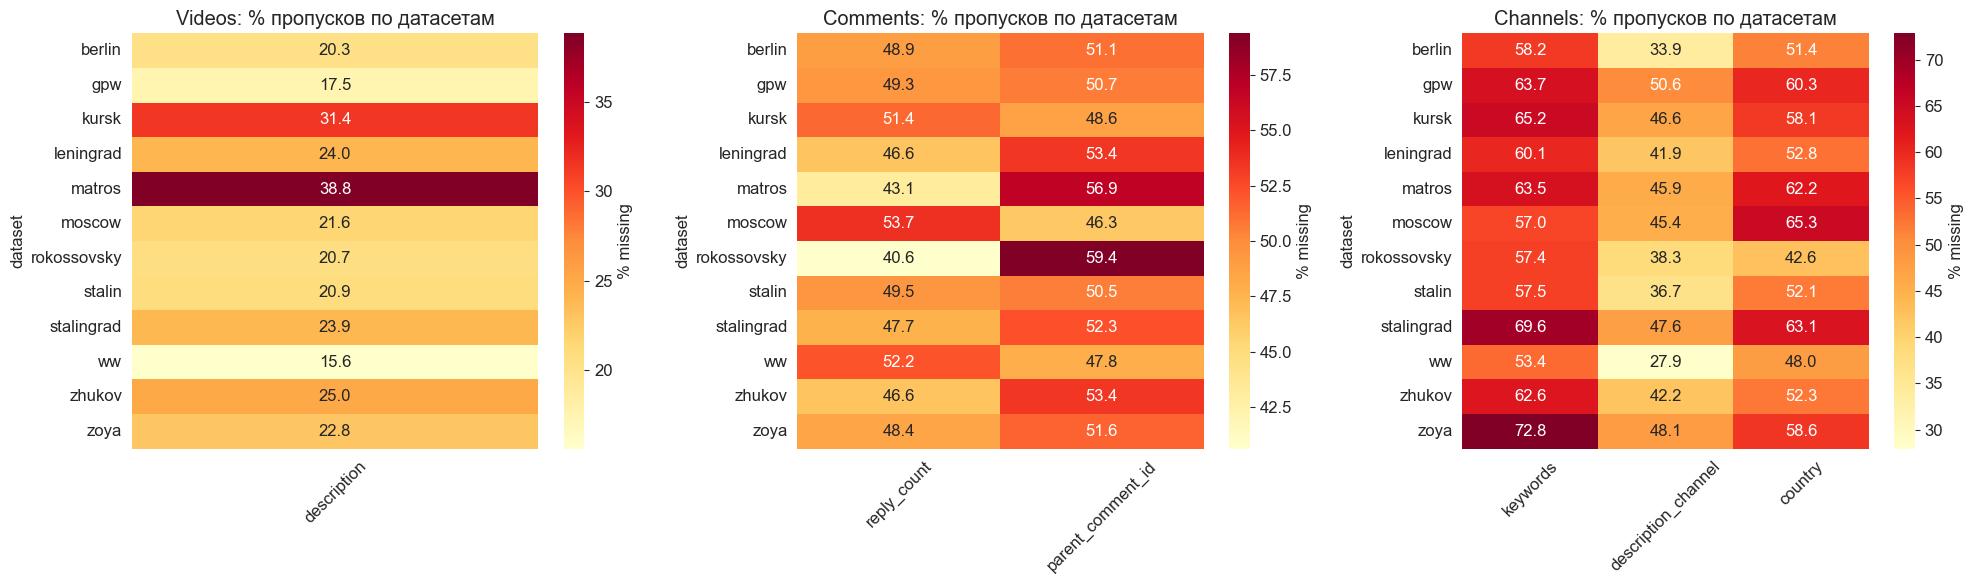

In [50]:
# Heatmap of missingness
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (df, title) in zip(axes, [(all_videos, 'Videos'), (all_comments, 'Comments'), (channels, 'Channels')]):
    cols_with_nulls = df.columns[df.isnull().any()].tolist()
    if cols_with_nulls:
        null_by_dataset = df.groupby('dataset')[cols_with_nulls].apply(lambda x: x.isnull().mean() * 100)
        sns.heatmap(null_by_dataset, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label': '% missing'})
    ax.set_title(f'{title}: % пропусков по датасетам')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.2 Дубликаты

In [51]:
# Video duplicates across datasets
video_dup_mask = all_videos.duplicated(subset='video_id', keep=False)
n_dup_video_records = video_dup_mask.sum()
n_unique_videos = all_videos['video_id'].nunique()
print(f'Видео: {len(all_videos):,} записей, {n_unique_videos:,} уникальных video_id')
print(f'  Дублирующихся записей (одно видео в нескольких датасетах): {n_dup_video_records:,}')

# Comment duplicates
comment_dup_mask = all_comments.duplicated(subset='comment_id', keep=False)
n_dup_comments = comment_dup_mask.sum()
n_unique_comments = all_comments['comment_id'].nunique()
print(f'\nКомментарии: {len(all_comments):,} записей, {n_unique_comments:,} уникальных comment_id')
print(f'  Дублирующихся записей: {n_dup_comments:,}')

Видео: 50,999 записей, 44,961 уникальных video_id
  Дублирующихся записей (одно видео в нескольких датасетах): 11,365

Комментарии: 4,825,616 записей, 3,764,945 уникальных comment_id
  Дублирующихся записей: 1,882,612


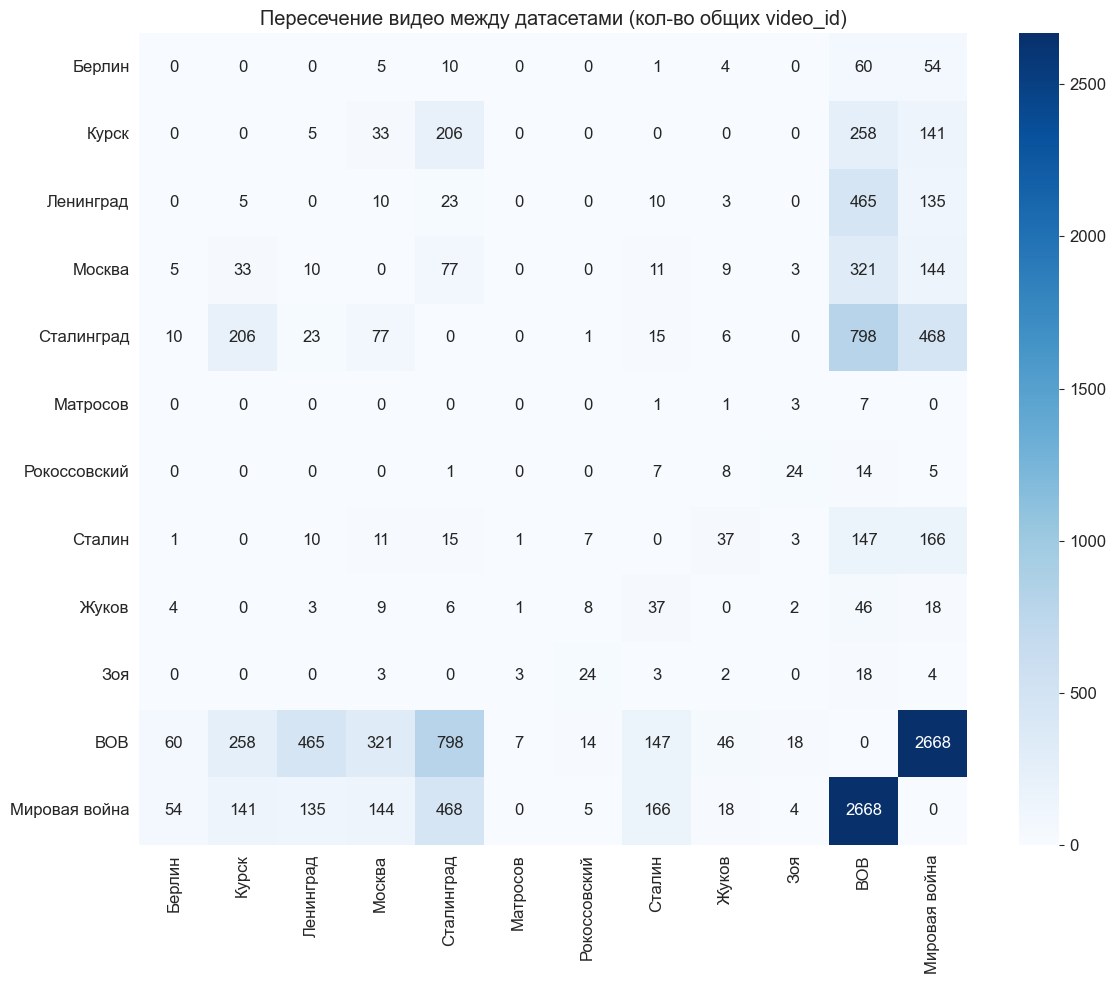

In [52]:
# Which datasets share the most video duplicates?
dup_videos = all_videos[video_dup_mask][['video_id', 'dataset']].drop_duplicates()
video_ds_sets = dup_videos.groupby('video_id')['dataset'].apply(frozenset)

# Build cross-dataset overlap matrix for videos
ds_names = list(DATASETS.keys())
overlap_matrix = pd.DataFrame(0, index=ds_names, columns=ds_names)

for ds_set in video_ds_sets:
    ds_list = list(ds_set)
    for i in range(len(ds_list)):
        for j in range(len(ds_list)):
            if i != j:
                overlap_matrix.loc[ds_list[i], ds_list[j]] += 1

fig, ax = plt.subplots(figsize=(12, 10))
labels_ru = [DATASETS[d]['label'] for d in ds_names]
sns.heatmap(overlap_matrix.values, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_ru, yticklabels=labels_ru, ax=ax)
ax.set_title('Пересечение видео между датасетами (кол-во общих video_id)')
plt.tight_layout()
plt.show()

### 2.3 Диапазоны дат

Диапазон дат публикации видео по датасетам:


,min,max
Мировая война,2007-05-04 08:06:09,2025-05-09 11:43:08
Москва,2007-05-24 18:53:30,2025-05-23 17:04:44
Ленинград,2007-08-21 22:39:47,2025-04-29 18:12:34
ВОВ,2007-10-10 14:28:05,2025-05-04 06:45:01
Сталинград,2008-02-02 22:28:50,2025-05-06 03:00:17
Курск,2008-02-17 10:09:21,2025-05-05 15:03:21
Берлин,2008-03-08 19:21:31,2025-05-07 07:00:48
Сталин,2008-03-10 10:37:10,2025-05-02 13:19:44
Жуков,2009-02-24 04:11:43,2025-05-01 05:58:14
Матросов,2009-09-12 19:14:39,2025-04-08 05:40:04


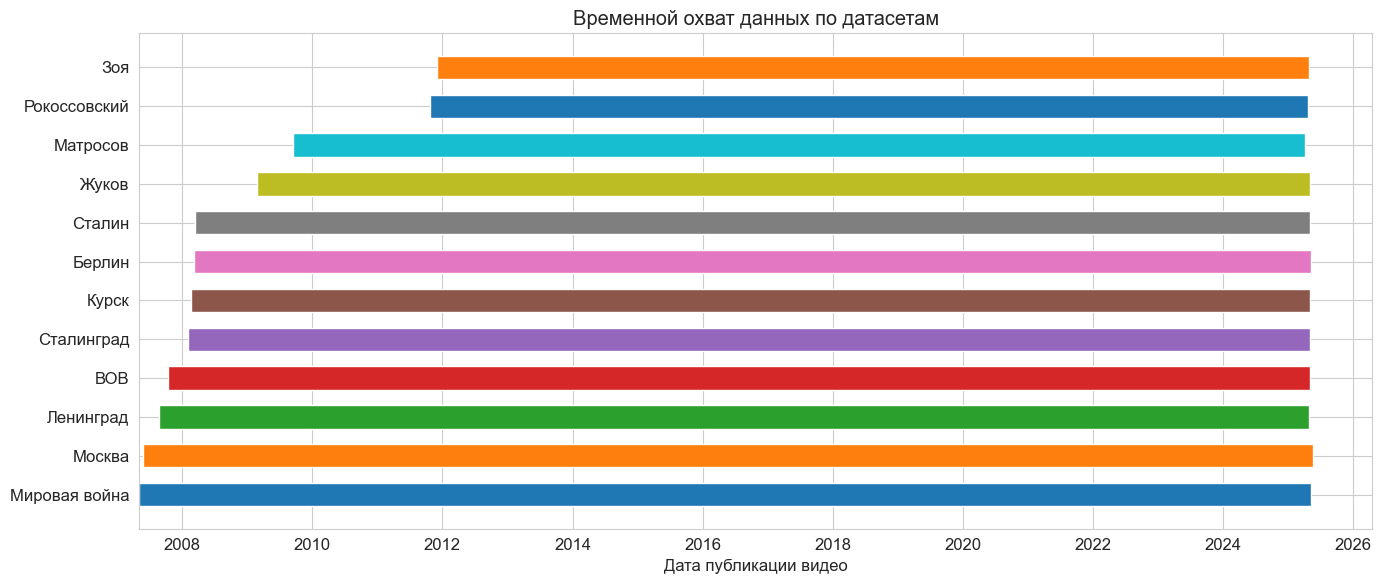

In [53]:
# Date ranges per dataset
date_ranges = all_videos.groupby('dataset')['publish_date'].agg(['min', 'max']).sort_values('min')
date_ranges.index = [DATASETS[d]['label'] for d in date_ranges.index]
print('Диапазон дат публикации видео по датасетам:')
display(date_ranges)

# Visual timeline
fig, ax = plt.subplots(figsize=(14, 6))
for i, (idx, row) in enumerate(date_ranges.iterrows()):
    ax.barh(i, (row['max'] - row['min']).days, left=row['min'], height=0.6, label=idx)
ax.set_yticks(range(len(date_ranges)))
ax.set_yticklabels(date_ranges.index)
ax.set_title('Временной охват данных по датасетам')
ax.set_xlabel('Дата публикации видео')
plt.tight_layout()
plt.show()

### 2.4 Выбросы в метриках

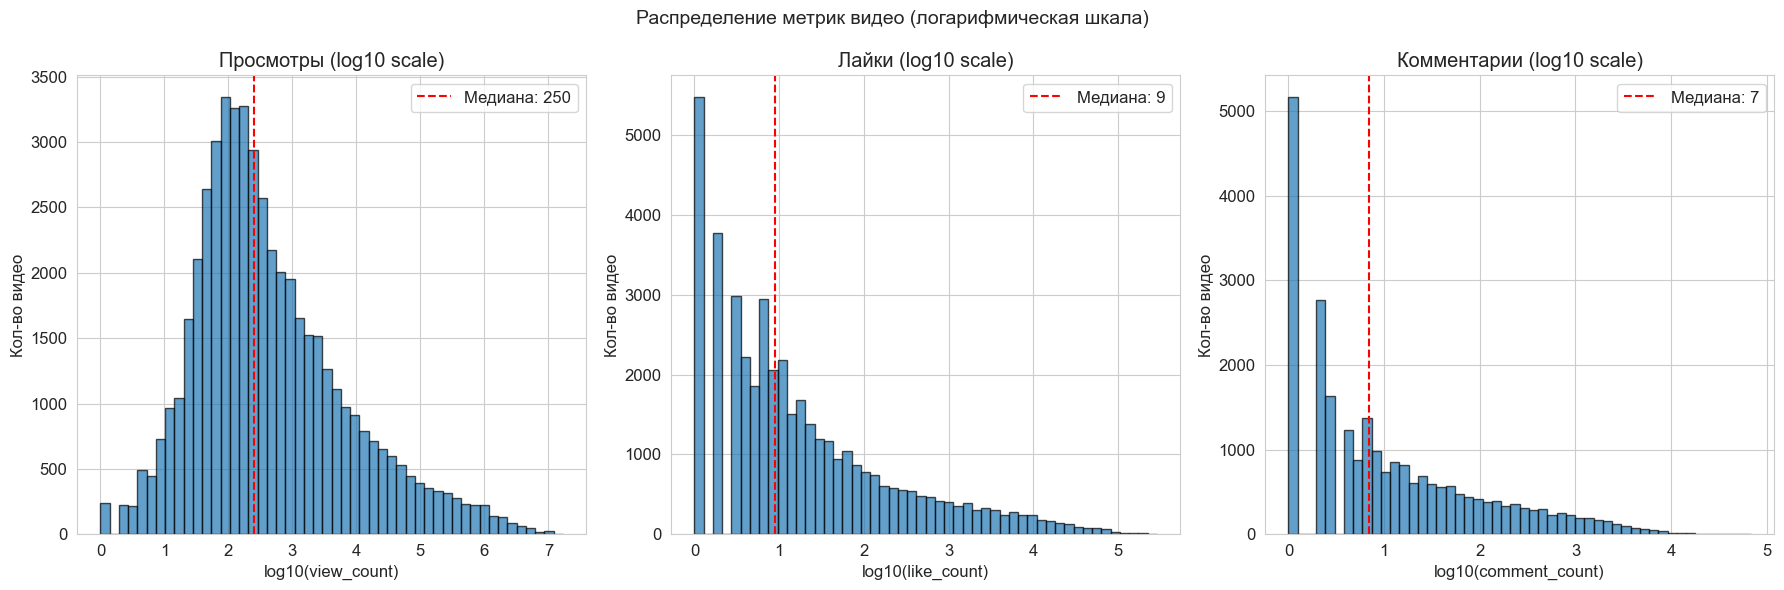

Статистика метрик видео:


,view_count,like_count,comment_count
count,50999.0,50999.0,50999.0
mean,51176.0,985.0,105.0
std,400083.0,7191.0,762.0
min,0.0,0.0,0.0
25%,67.0,1.0,0.0
50%,249.0,6.0,0.0
75%,1948.0,38.0,6.0
max,16812686.0,288279.0,68076.0


In [54]:
# Ensure numeric types
for col in ['view_count', 'like_count', 'comment_count']:
    all_videos[col] = pd.to_numeric(all_videos[col], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col, title in zip(axes, ['view_count', 'like_count', 'comment_count'],
                           ['Просмотры', 'Лайки', 'Комментарии']):
    data = all_videos[col].dropna()
    data_log = np.log10(data[data > 0])
    ax.hist(data_log, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'{title} (log10 scale)')
    ax.set_xlabel(f'log10({col})')
    ax.set_ylabel('Кол-во видео')
    ax.axvline(data_log.median(), color='red', linestyle='--', label=f'Медиана: {10**data_log.median():.0f}')
    ax.legend()

plt.suptitle('Распределение метрик видео (логарифмическая шкала)', fontsize=14)
plt.tight_layout()
plt.show()

# Summary stats
print('Статистика метрик видео:')
display(all_videos[['view_count', 'like_count', 'comment_count']].describe().round(0))

### 2.5 Шум: распределение YouTube-категорий

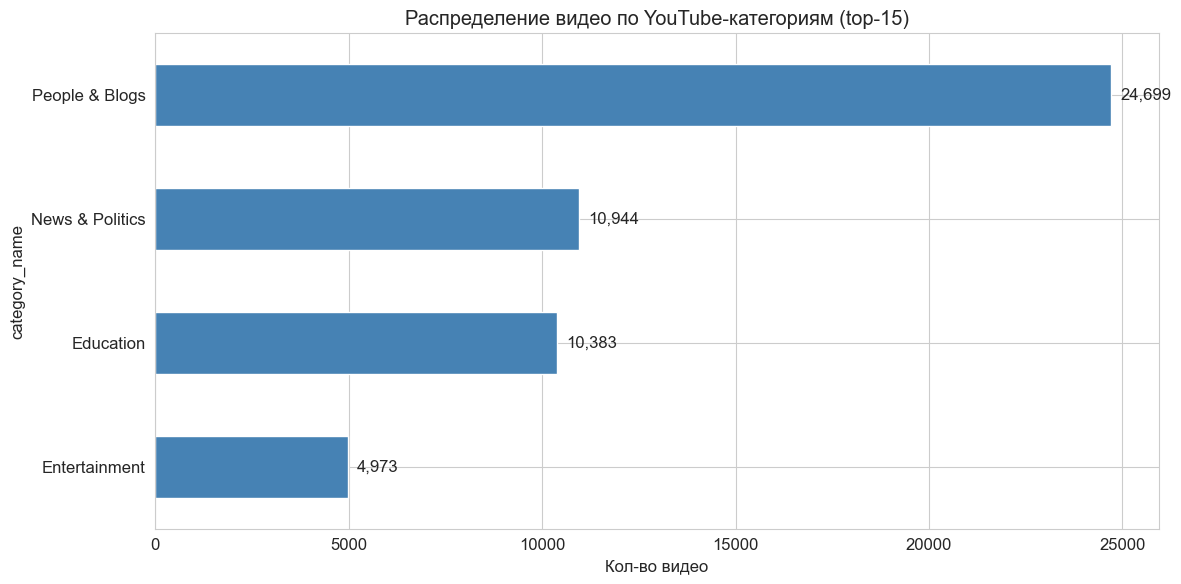

In [55]:
all_videos['category'] = pd.to_numeric(all_videos['category'], errors='coerce')
all_videos['category_name'] = all_videos['category'].map(YT_CATEGORIES).fillna('Unknown')

cat_counts = all_videos['category_name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
cat_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Распределение видео по YouTube-категориям (top-15)')
ax.set_xlabel('Кол-во видео')
ax.invert_yaxis()
for i, v in enumerate(cat_counts.values):
    ax.text(v + cat_counts.values[0]*0.01, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()

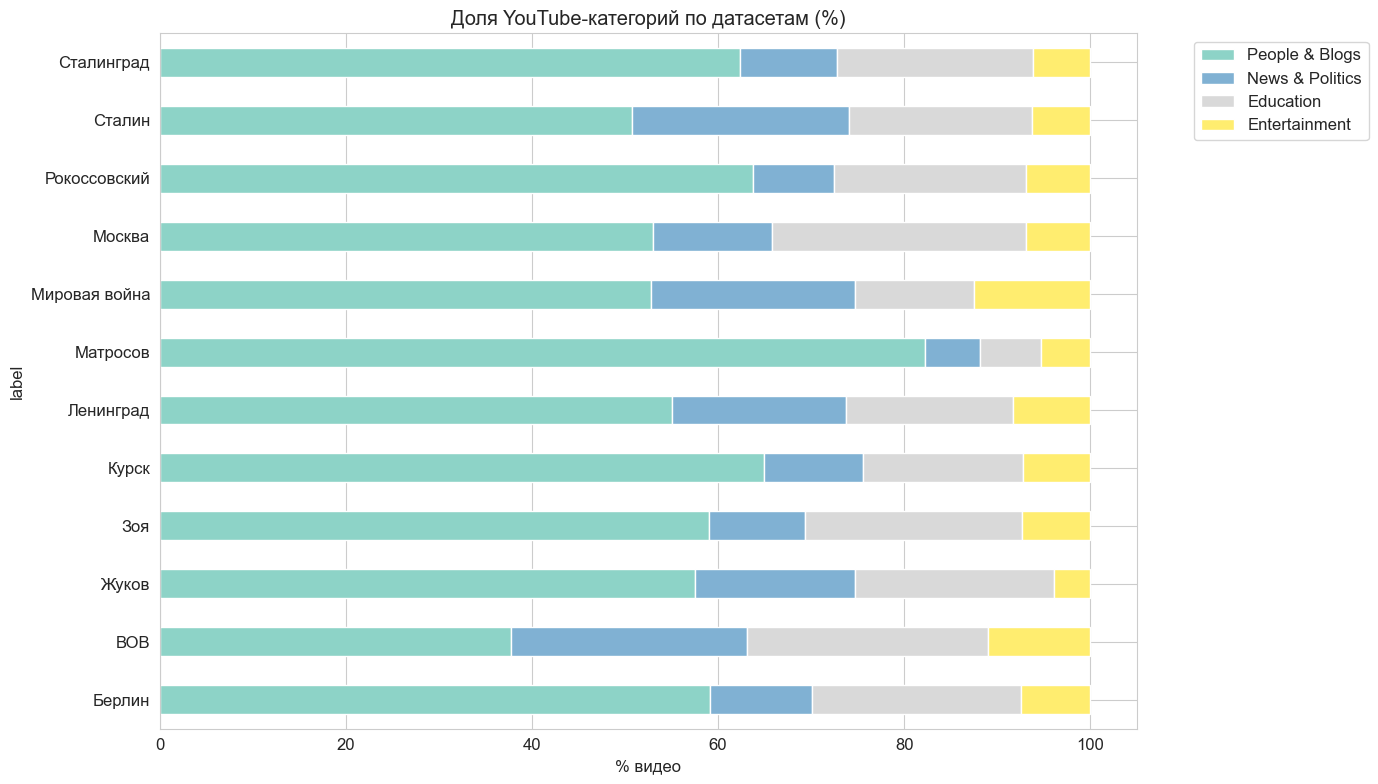

In [56]:
# Category distribution per dataset
cat_by_ds = pd.crosstab(all_videos['label'], all_videos['category_name'], normalize='index') * 100
top_cats = all_videos['category_name'].value_counts().head(8).index.tolist()
cat_by_ds = cat_by_ds[top_cats]

fig, ax = plt.subplots(figsize=(14, 8))
cat_by_ds.plot(kind='barh', stacked=True, ax=ax, colormap='Set3')
ax.set_title('Доля YouTube-категорий по датасетам (%)')
ax.set_xlabel('% видео')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.6 Осиротевшие комментарии

In [57]:
# Comments referencing video_ids not in our videos table
video_ids_in_videos = set(all_videos['video_id'].unique())
orphan_mask = ~all_comments['video_id'].isin(video_ids_in_videos)
n_orphans = orphan_mask.sum()
print(f'Комментарии к видео, отсутствующим в таблице videos: {n_orphans:,} ({n_orphans/len(all_comments)*100:.2f}%)')

if n_orphans > 0:
    orphan_by_ds = all_comments[orphan_mask].groupby('label').size().sort_values(ascending=False)
    print('\nПо датасетам:')
    display(orphan_by_ds)

Комментарии к видео, отсутствующим в таблице videos: 0 (0.00%)


---
## 3. Ландшафт каналов

### 3.1 Пересечения каналов между датасетами

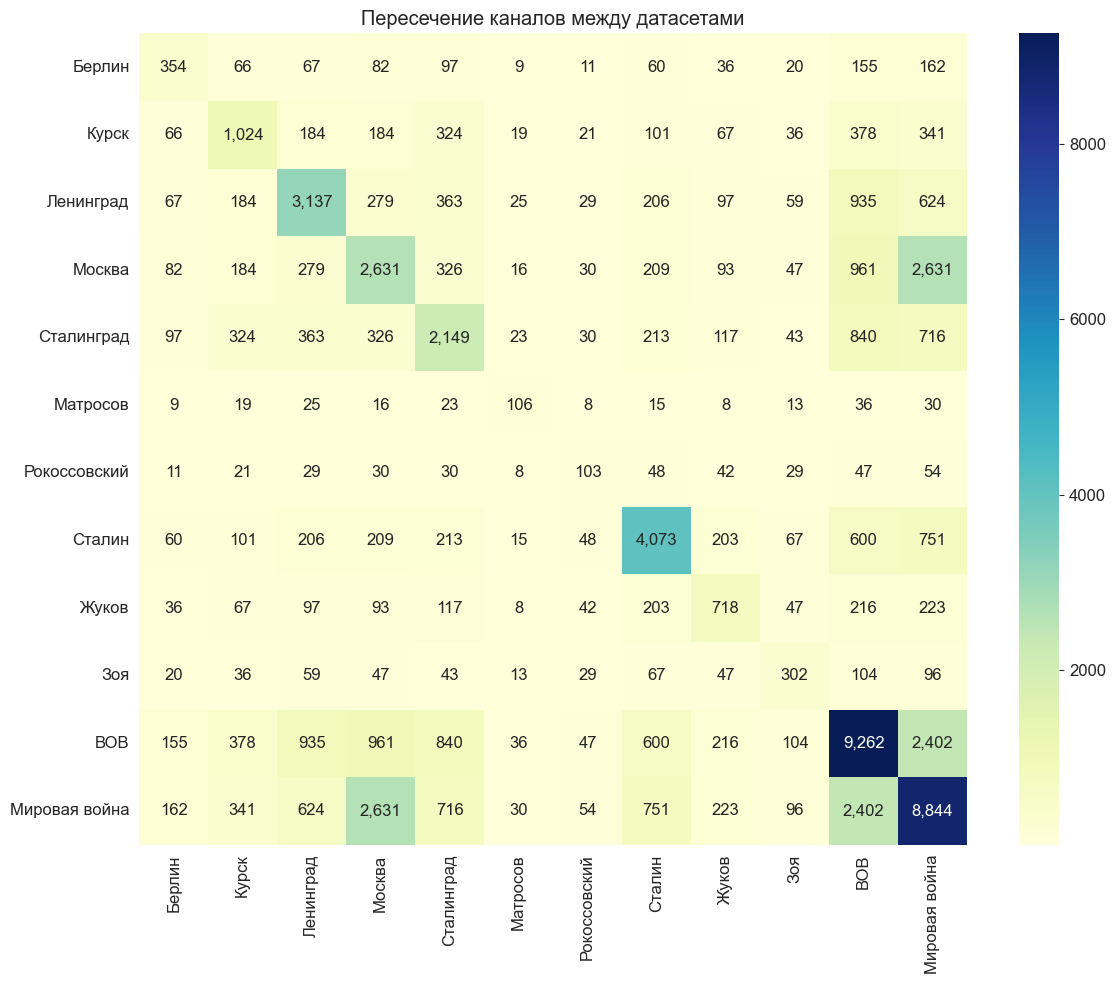

In [58]:
# Channel overlap heatmap
ds_names = list(DATASETS.keys())
channel_overlap = pd.DataFrame(0, index=ds_names, columns=ds_names)

channel_sets = {}
for ds in ds_names:
    channel_sets[ds] = set(all_channels_raw[all_channels_raw['dataset'] == ds]['id_channel'])

for i in ds_names:
    for j in ds_names:
        channel_overlap.loc[i, j] = len(channel_sets[i] & channel_sets[j])

labels_ru = [DATASETS[d]['label'] for d in ds_names]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(channel_overlap.values, annot=True, fmt=',d', cmap='YlGnBu',
            xticklabels=labels_ru, yticklabels=labels_ru, ax=ax)
ax.set_title('Пересечение каналов между датасетами')
plt.tight_layout()
plt.show()

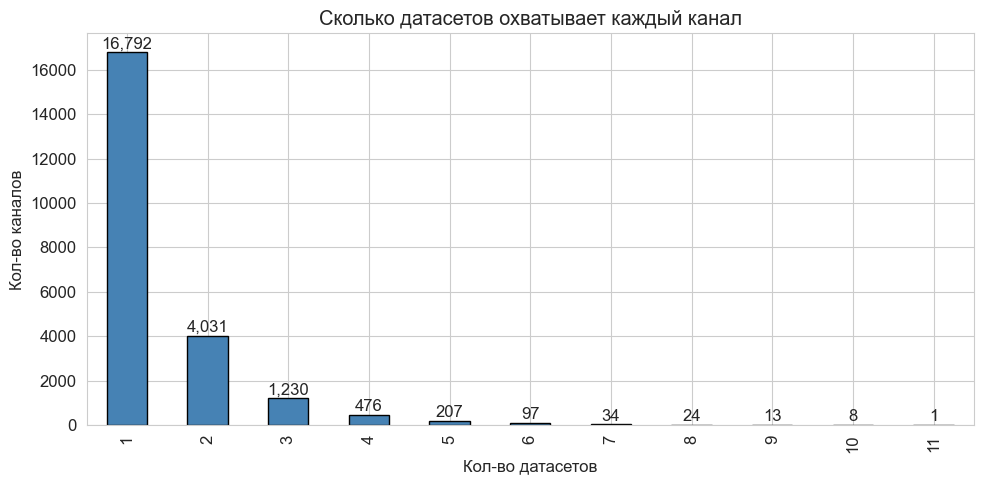

In [59]:
# How many datasets does each channel appear in?
fig, ax = plt.subplots(figsize=(10, 5))
n_topics_counts = channels['n_topics'].value_counts().sort_index()
n_topics_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Сколько датасетов охватывает каждый канал')
ax.set_xlabel('Кол-во датасетов')
ax.set_ylabel('Кол-во каналов')
for i, v in enumerate(n_topics_counts.values):
    ax.text(i, v + n_topics_counts.values.max()*0.01, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

### 3.2 Распределение размеров каналов

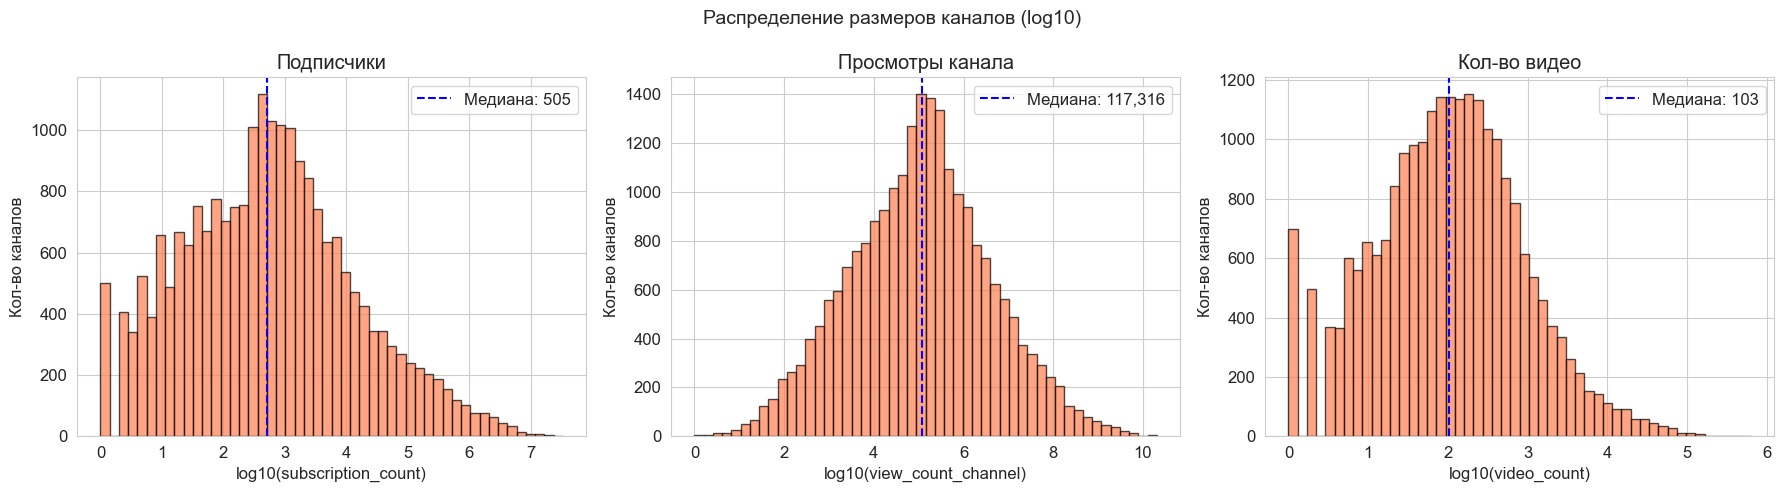

Статистика каналов:


,subscription_count,view_count_channel,video_count
count,22913.0,2.291300e+04,22913.0
mean,73472.0,3.119071e+07,1266.0
std,658695.0,3.630061e+08,9622.0
min,0.0,0.000000e+00,1.0
25%,39.0,9.610000e+03,24.0
50%,453.0,1.172680e+05,103.0
75%,3780.0,1.126755e+06,414.0
max,33300000.0,2.045892e+10,627292.0


In [60]:
for col in ['subscription_count', 'view_count_channel', 'video_count']:
    channels[col] = pd.to_numeric(channels[col], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('subscription_count', 'Подписчики'), ('view_count_channel', 'Просмотры канала'), ('video_count', 'Кол-во видео')]

for ax, (col, title) in zip(axes, metrics):
    data = channels[col].dropna()
    data = data[data > 0]
    ax.hist(np.log10(data), bins=50, edgecolor='black', alpha=0.7, color='coral')
    ax.set_title(title)
    ax.set_xlabel(f'log10({col})')
    ax.set_ylabel('Кол-во каналов')
    ax.axvline(np.log10(data.median()), color='blue', linestyle='--', label=f'Медиана: {data.median():,.0f}')
    ax.legend()

plt.suptitle('Распределение размеров каналов (log10)', fontsize=14)
plt.tight_layout()
plt.show()

print('Статистика каналов:')
display(channels[['subscription_count', 'view_count_channel', 'video_count']].describe().round(0))

### 3.3 География каналов

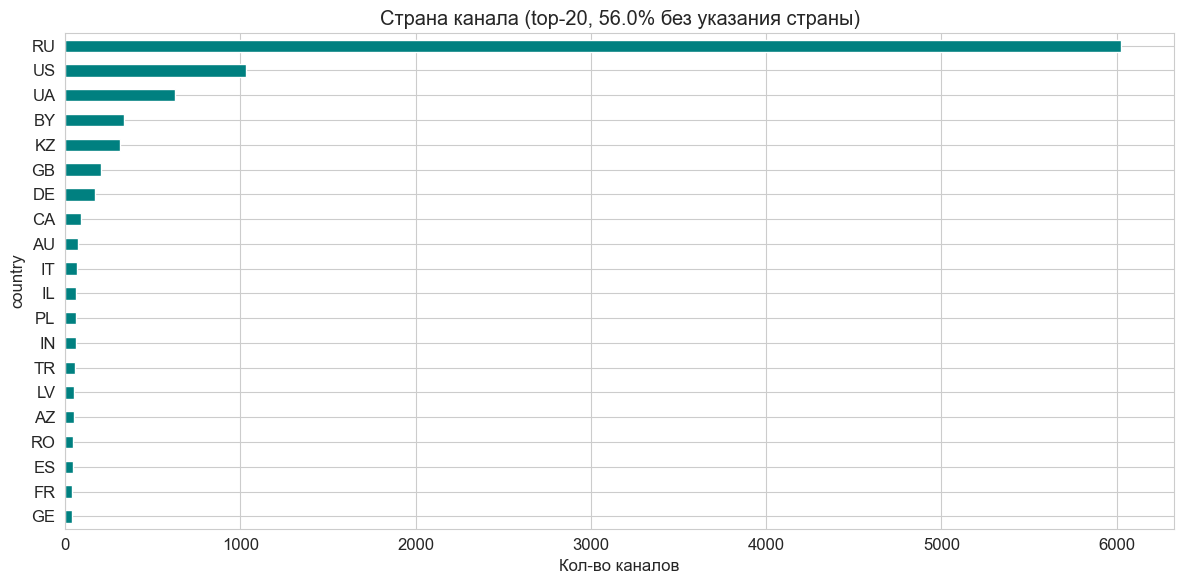

In [61]:
country_counts = channels['country'].value_counts().head(20)
missing_country_pct = channels['country'].isna().mean() * 100

fig, ax = plt.subplots(figsize=(12, 6))
country_counts.plot(kind='barh', ax=ax, color='teal')
ax.set_title(f'Страна канала (top-20, {missing_country_pct:.1f}% без указания страны)')
ax.set_xlabel('Кол-во каналов')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 3.4 Год создания каналов

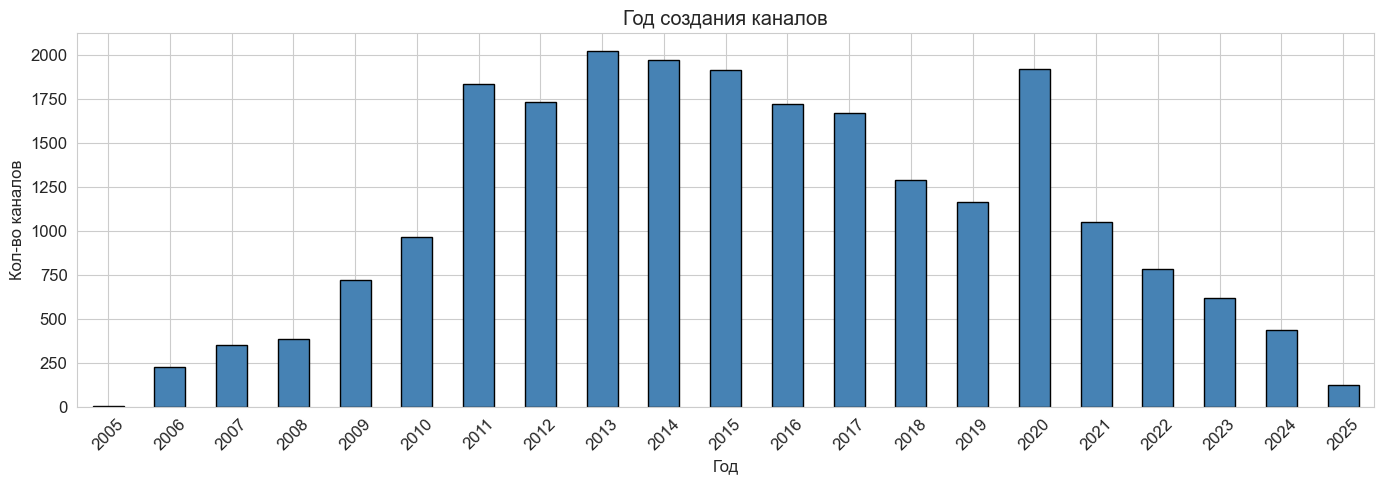

In [62]:
channels['creation_year'] = channels['account_creation_date'].dt.year
creation_by_year = channels['creation_year'].value_counts().sort_index()
creation_by_year = creation_by_year[creation_by_year.index >= 2005]  # filter anomalies

fig, ax = plt.subplots(figsize=(14, 5))
creation_by_year.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Год создания каналов')
ax.set_xlabel('Год')
ax.set_ylabel('Кол-во каналов')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 4. Классификация каналов: фокус на историю

In [63]:
# History-related keywords
HISTORY_KEYWORDS = {
    'история', 'исторический', 'историк', 'историч',
    'война', 'военный', 'военная', 'фронт', 'фронтовой',
    'вов', 'великая отечественная', 'вторая мировая', 'wwii', 'ww2', 'world war',
    'ссср', 'советский', 'советская', 'красная армия',
    'сталинград', 'берлин', 'курск', 'ленинград', 'блокада', 'москва',
    'сталин', 'жуков', 'рокоссовский', 'матросов',
    'победа', 'ветеран', 'герой', 'подвиг', 'память',
    'вермахт', 'рейх', 'нацизм', 'фашизм', 'холокост',
    'документальный', 'documentary', 'history',
    'танк', 'авиация', 'флот', 'артиллерия', 'оружие',
    'битва', 'сражение', 'операция', 'наступление', 'оборона',
}

def keyword_score(text, keywords=HISTORY_KEYWORDS):
    """Fraction of keywords found in text."""
    if pd.isna(text) or not isinstance(text, str):
        return 0.0
    text_lower = text.lower()
    matches = sum(1 for kw in keywords if kw in text_lower)
    return matches / len(keywords)

# Score each channel
channels['kw_score_keywords'] = channels['keywords'].apply(keyword_score)
channels['kw_score_desc'] = channels['description_channel'].apply(keyword_score)
channels['kw_score_title'] = channels['title_channel'].apply(keyword_score)

# Topic breadth (normalized 0-1)
channels['topic_breadth'] = channels['n_topics'] / channels['n_topics'].max()

# Category signal: what fraction of a channel's videos are in "history-friendly" categories
history_categories = {22, 25, 27}  # People & Blogs, News & Politics, Education
channel_cat_frac = (all_videos.assign(is_hist_cat=all_videos['category'].isin(history_categories))
                    .groupby('channel_id')['is_hist_cat'].mean()
                    .reset_index()
                    .rename(columns={'is_hist_cat': 'hist_cat_frac', 'channel_id': 'id_channel'}))
channels = channels.merge(channel_cat_frac, on='id_channel', how='left')
channels['hist_cat_frac'] = channels['hist_cat_frac'].fillna(0)

# Composite score
channels['history_score'] = (
    0.25 * channels['kw_score_keywords'] +
    0.20 * channels['kw_score_desc'] +
    0.15 * channels['kw_score_title'] +
    0.20 * channels['topic_breadth'] +
    0.20 * channels['hist_cat_frac']
)

print(f'History score: min={channels["history_score"].min():.3f}, '
      f'median={channels["history_score"].median():.3f}, '
      f'max={channels["history_score"].max():.3f}')

History score: min=0.018, median=0.218, max=0.416


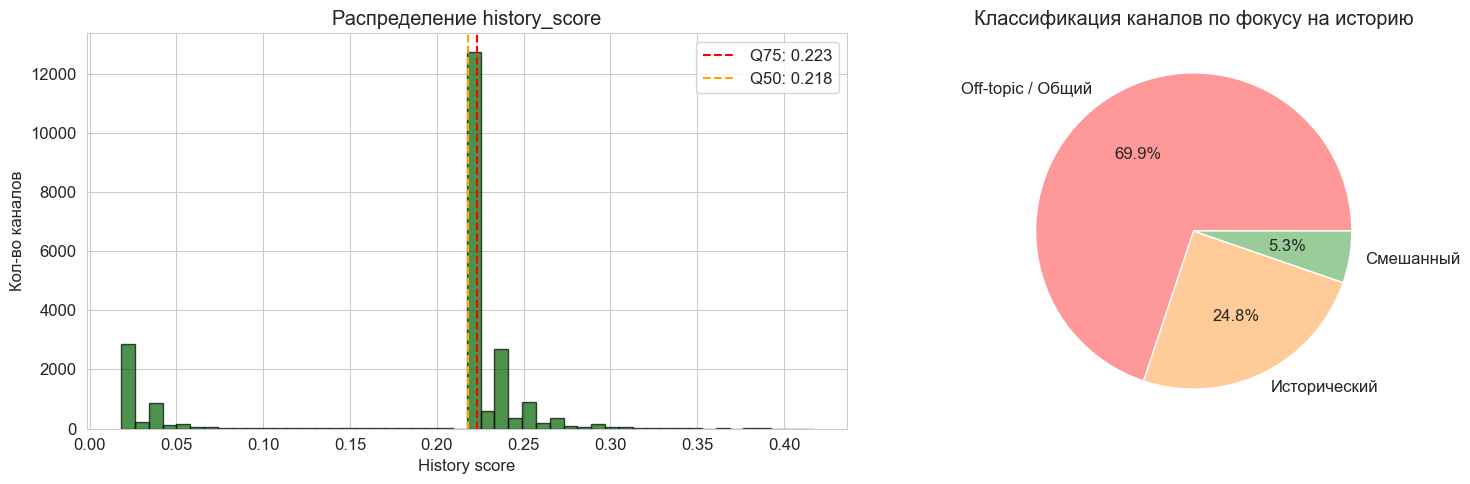


Классификация каналов:
  Исторический: 5,691 каналов (24.8%)
  Смешанный: 1,213 каналов (5.3%)
  Off-topic / Общий: 16,009 каналов (69.9%)


In [64]:
# Score distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(channels['history_score'], bins=50, edgecolor='black', alpha=0.7, color='darkgreen')
axes[0].set_title('Распределение history_score')
axes[0].set_xlabel('History score')
axes[0].set_ylabel('Кол-во каналов')

# Thresholds
q75 = channels['history_score'].quantile(0.75)
q50 = channels['history_score'].quantile(0.50)
axes[0].axvline(q75, color='red', linestyle='--', label=f'Q75: {q75:.3f}')
axes[0].axvline(q50, color='orange', linestyle='--', label=f'Q50: {q50:.3f}')
axes[0].legend()

# Classify
channels['history_class'] = pd.cut(channels['history_score'],
                                    bins=[-0.01, q50, q75, 1.01],
                                    labels=['Off-topic / Общий', 'Смешанный', 'Исторический'])

# Pie
class_counts = channels['history_class'].value_counts()
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=['#ff9999', '#ffcc99', '#99cc99'])
axes[1].set_title('Классификация каналов по фокусу на историю')

plt.tight_layout()
plt.show()

print(f'\nКлассификация каналов:')
for cls in ['Исторический', 'Смешанный', 'Off-topic / Общий']:
    n = (channels['history_class'] == cls).sum()
    print(f'  {cls}: {n:,} каналов ({n/len(channels)*100:.1f}%)')

In [65]:
# Top-50 history-focused channels
top_history = (channels.nlargest(50, 'history_score')
               [['title_channel', 'subscription_count', 'video_count', 'n_topics', 'history_score', 'history_class']]
               .reset_index(drop=True))
top_history.index += 1
top_history.columns = ['Канал', 'Подписчики', 'Видео', 'Датасетов', 'Score', 'Класс']
display(top_history.style.format({'Подписчики': '{:,.0f}', 'Видео': '{:,.0f}', 'Score': '{:.3f}'}))

,Канал,Подписчики,Видео,Датасетов,Score,Класс
1,Black History,"48,900",517,11,0.416,Исторический
2,ИСТОРИЯ.РФ,"206,000",905,10,0.415,Исторический
3,Историческая Эпоха,"305,000",856,9,0.413,Исторический
4,Блиндаж,"211,000",291,8,0.412,Исторический
5,Истории,"18,000","3,865",10,0.401,Исторический
6,Великая Отечественная,"6,670",95,8,0.399,Исторический
7,Фронтовая кинолетопись,"183,000",148,7,0.394,Исторический
8,Рассказы Великая Отечественная война,"23,000",324,8,0.393,Исторический
9,СЛЕД ИСТОРИИ,"245,000",464,9,0.388,Исторический
10,За Мир,"2,490",945,9,0.387,Исторический


In [66]:
# Scatter: history_score vs n_topics, sized by subscribers
plot_df = channels[channels['subscription_count'] > 0].copy()
plot_df['log_subs'] = np.log10(plot_df['subscription_count'])

fig = px.scatter(plot_df.sample(min(5000, len(plot_df)), random_state=42),
                 x='n_topics', y='history_score',
                 size='log_subs', color='history_class',
                 hover_data=['title_channel', 'subscription_count'],
                 title='History Score vs кол-во датасетов (размер = log подписчиков)',
                 color_discrete_map={'Исторический': 'green', 'Смешанный': 'orange', 'Off-topic / Общий': 'red'})
fig.update_layout(height=600)
fig.show()

---
## 5. Комментарии по годам

### 5.1 Общее количество комментариев по годам

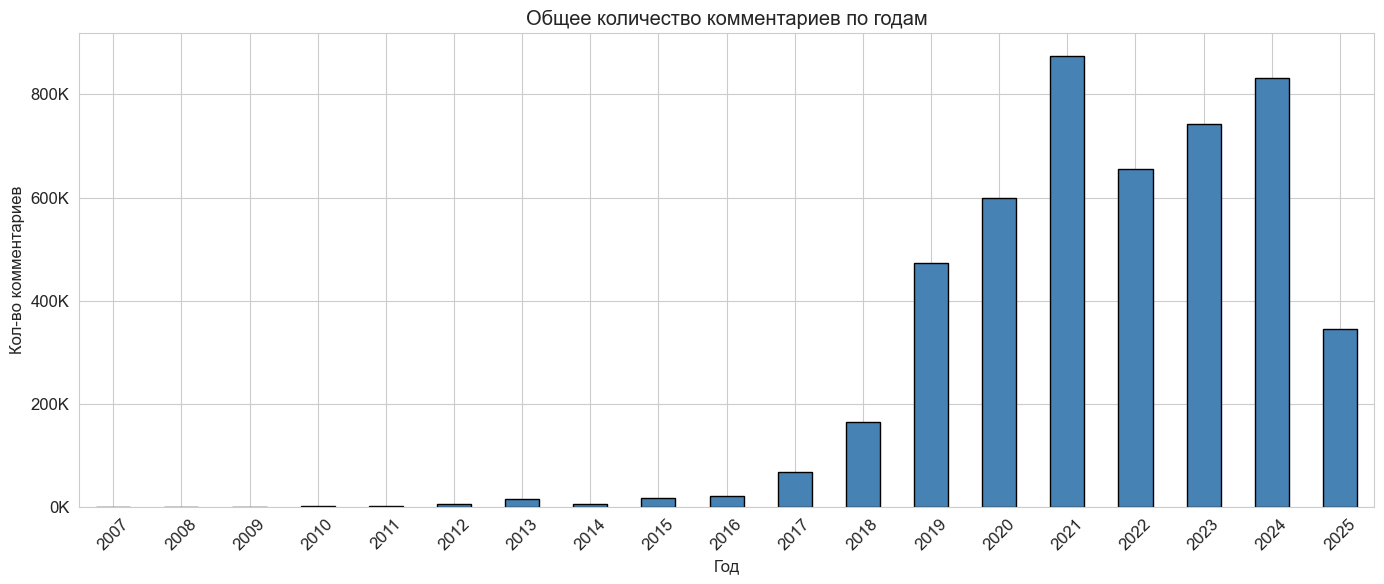

In [67]:
all_comments['year'] = all_comments['comment_publish_date'].dt.year

comments_by_year = all_comments['year'].value_counts().sort_index()
comments_by_year = comments_by_year[comments_by_year.index >= 2005]

fig, ax = plt.subplots(figsize=(14, 6))
comments_by_year.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Общее количество комментариев по годам')
ax.set_xlabel('Год')
ax.set_ylabel('Кол-во комментариев')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 5.2 Комментарии по годам — по группам (события / личности / широкие)

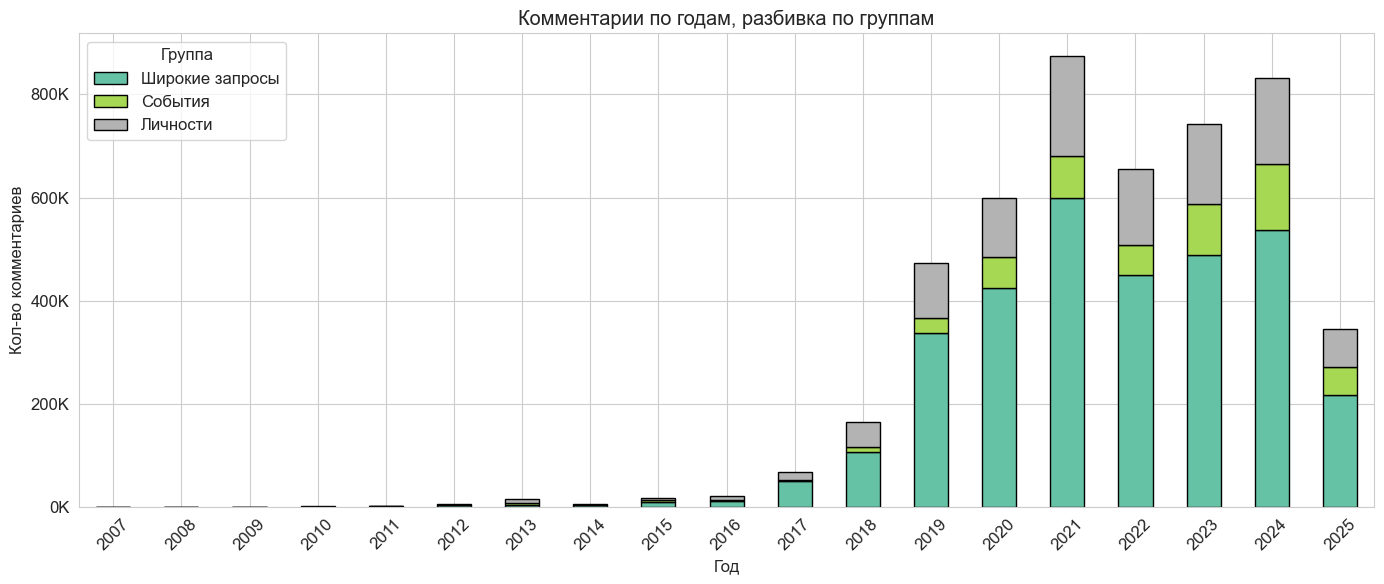

In [68]:
comments_year_group = (all_comments[all_comments['year'] >= 2005]
                       .groupby(['year', 'group']).size()
                       .unstack(fill_value=0))
comments_year_group.columns = [GROUP_LABELS.get(c, c) for c in comments_year_group.columns]

fig, ax = plt.subplots(figsize=(14, 6))
comments_year_group.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Комментарии по годам, разбивка по группам')
ax.set_xlabel('Год')
ax.set_ylabel('Кол-во комментариев')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax.legend(title='Группа')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 5.3 Комментарии по годам — отдельно по каждому датасету

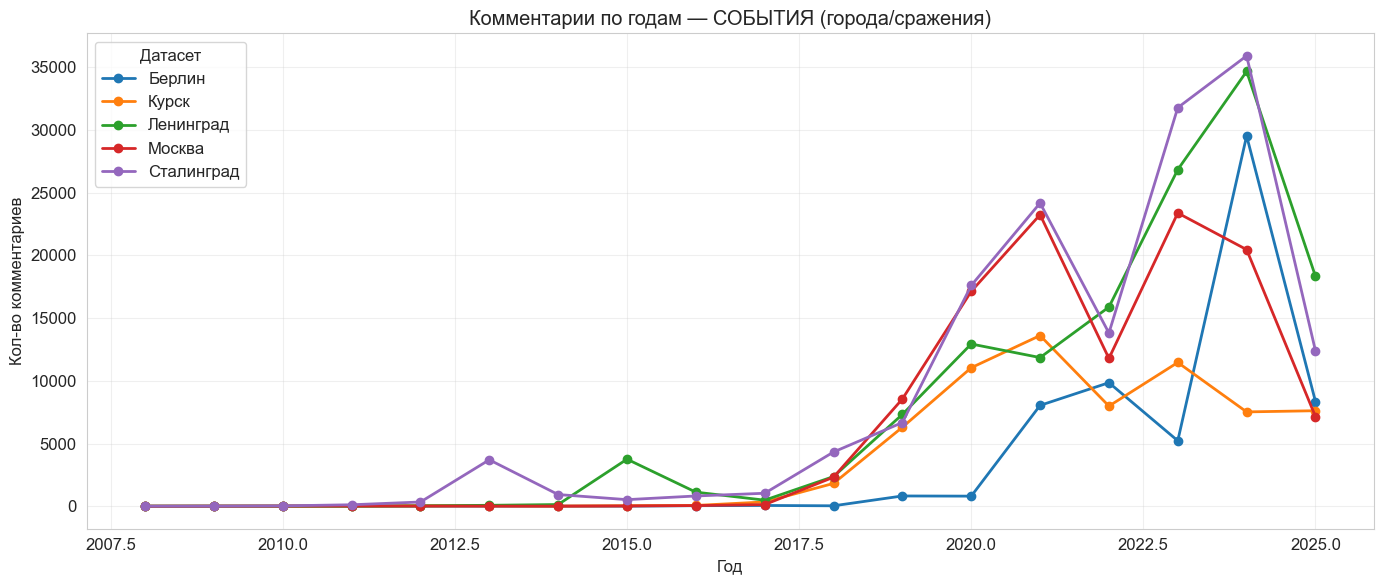

In [69]:
# Events
event_datasets = [d for d, info in DATASETS.items() if info['group'] == 'events']
comments_year_events = (all_comments[all_comments['dataset'].isin(event_datasets) & (all_comments['year'] >= 2005)]
                        .groupby(['year', 'label']).size()
                        .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 6))
comments_year_events.plot(kind='line', ax=ax, marker='o', linewidth=2)
ax.set_title('Комментарии по годам — СОБЫТИЯ (города/сражения)')
ax.set_xlabel('Год')
ax.set_ylabel('Кол-во комментариев')
ax.legend(title='Датасет')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

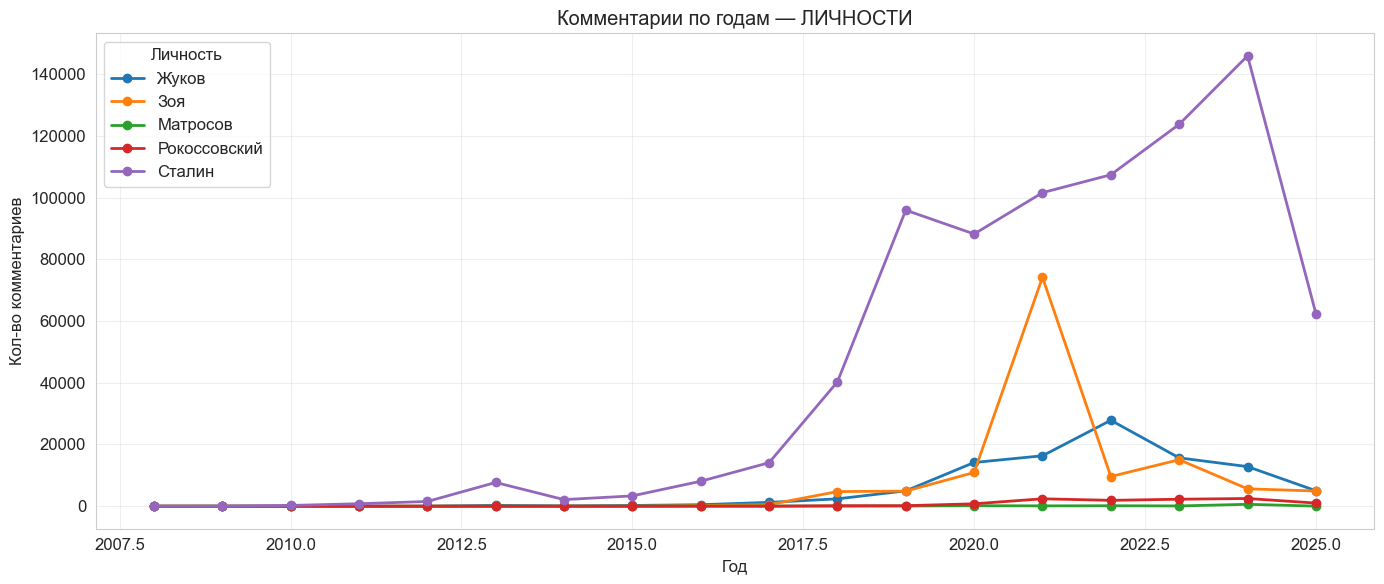

In [70]:
# Persons
person_datasets = [d for d, info in DATASETS.items() if info['group'] == 'person']
comments_year_persons = (all_comments[all_comments['dataset'].isin(person_datasets) & (all_comments['year'] >= 2005)]
                         .groupby(['year', 'label']).size()
                         .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 6))
comments_year_persons.plot(kind='line', ax=ax, marker='o', linewidth=2)
ax.set_title('Комментарии по годам — ЛИЧНОСТИ')
ax.set_xlabel('Год')
ax.set_ylabel('Кол-во комментариев')
ax.legend(title='Личность')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Динамика комментариев на самых обсуждаемых видео

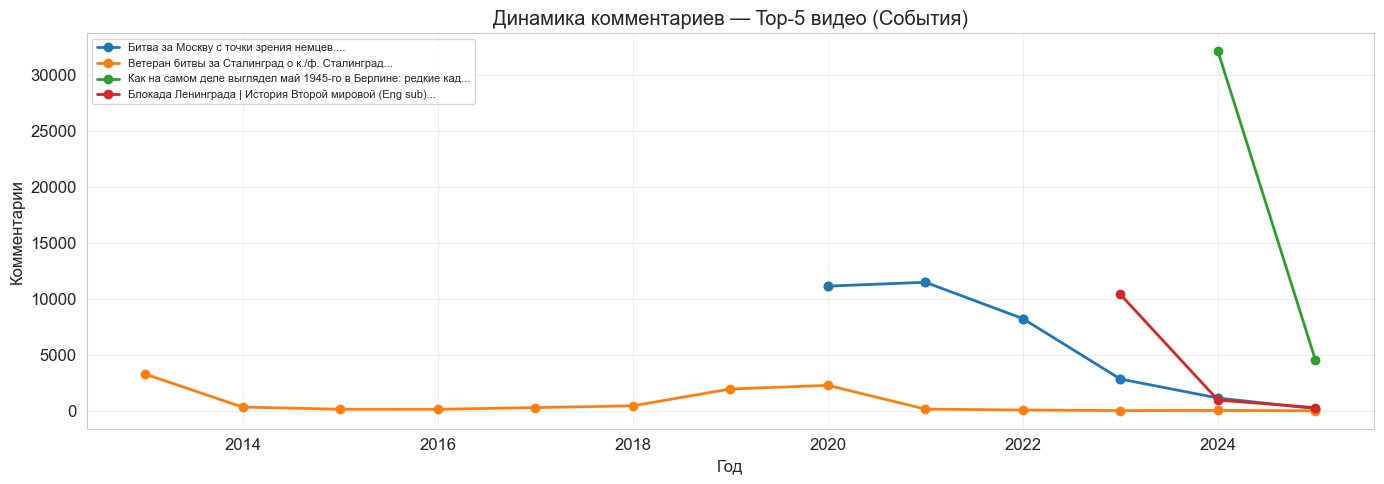

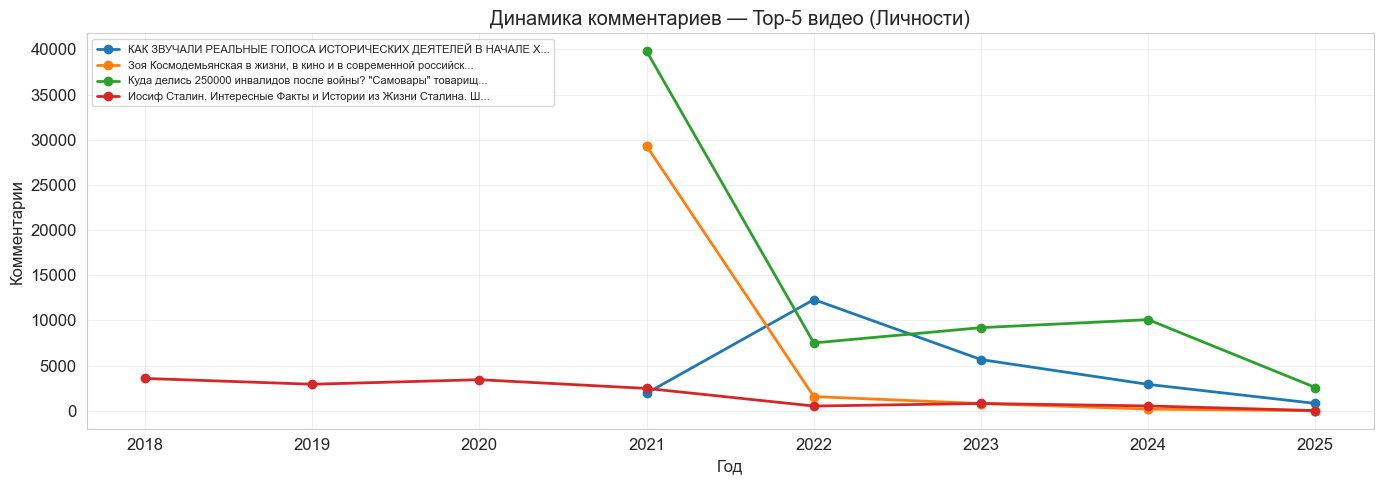

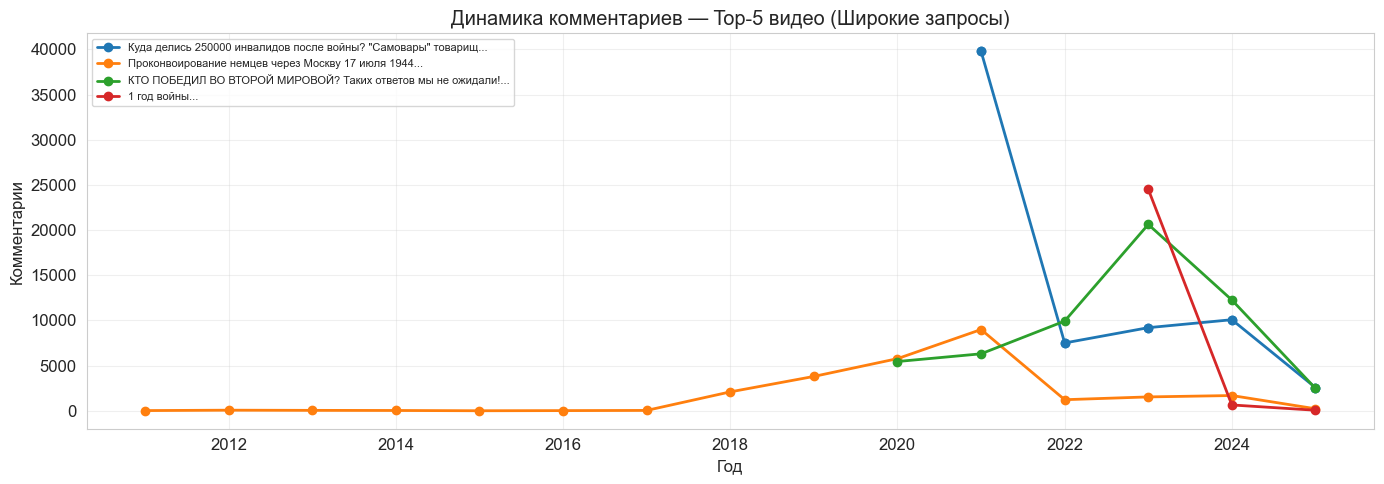

In [71]:
# Top-5 most-commented videos per group
for group_name, group_label in GROUP_LABELS.items():
    group_videos = all_videos[all_videos['group'] == group_name].nlargest(5, 'comment_count')
    if len(group_videos) == 0:
        continue
    
    top_vids = group_videos[['video_id', 'title', 'dataset', 'comment_count']].copy()
    top_vids['short_title'] = top_vids['title'].str[:60] + '...'
    
    # Get comments for these videos
    top_comments = all_comments[all_comments['video_id'].isin(top_vids['video_id'].values)]
    top_comments_year = top_comments.groupby(['video_id', 'year']).size().reset_index(name='count')
    top_comments_year = top_comments_year.merge(top_vids[['video_id', 'short_title']], on='video_id')
    
    fig, ax = plt.subplots(figsize=(14, 5))
    for vid_title in top_comments_year['short_title'].unique():
        vdata = top_comments_year[top_comments_year['short_title'] == vid_title]
        ax.plot(vdata['year'], vdata['count'], marker='o', label=vid_title, linewidth=2)
    
    ax.set_title(f'Динамика комментариев — Top-5 видео ({group_label})')
    ax.set_xlabel('Год')
    ax.set_ylabel('Комментарии')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 5.5 Публикация видео по годам

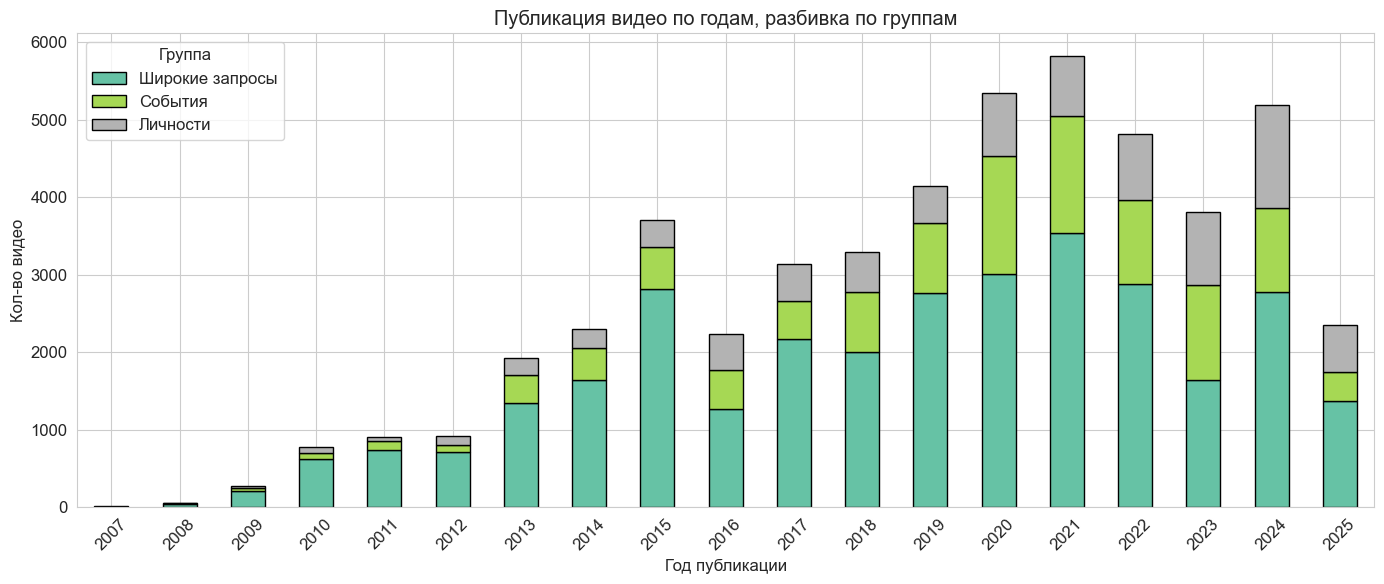

In [72]:
all_videos['publish_year'] = all_videos['publish_date'].dt.year

videos_by_year_ds = (all_videos[all_videos['publish_year'] >= 2005]
                     .groupby(['publish_year', 'group']).size()
                     .unstack(fill_value=0))
videos_by_year_ds.columns = [GROUP_LABELS.get(c, c) for c in videos_by_year_ds.columns]

fig, ax = plt.subplots(figsize=(14, 6))
videos_by_year_ds.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Публикация видео по годам, разбивка по группам')
ax.set_xlabel('Год публикации')
ax.set_ylabel('Кол-во видео')
ax.legend(title='Группа')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 6. Анализ вовлечённости

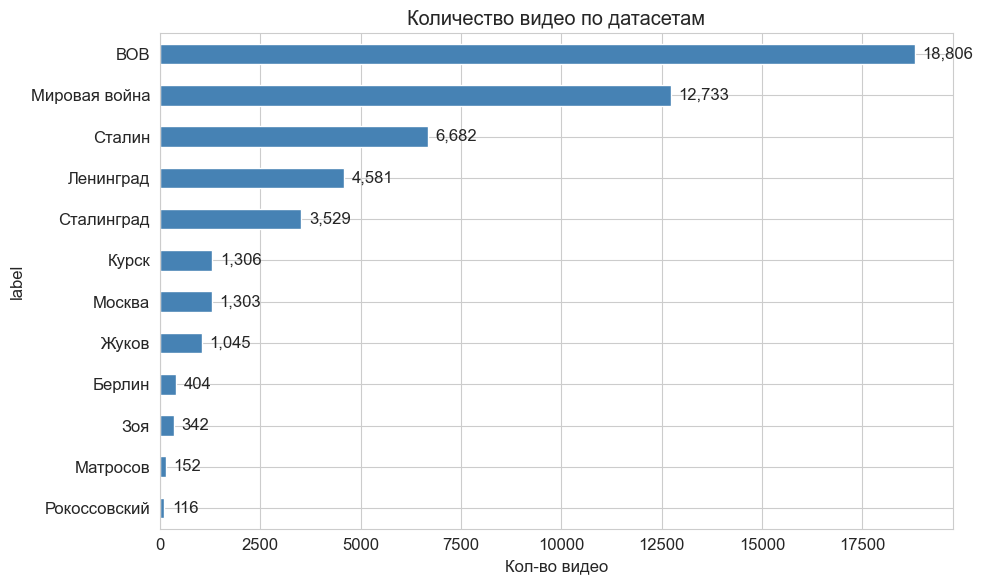

In [73]:
# Videos per dataset
videos_per_ds = all_videos.groupby('label').size().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
videos_per_ds.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Количество видео по датасетам')
ax.set_xlabel('Кол-во видео')
for i, v in enumerate(videos_per_ds.values):
    ax.text(v + videos_per_ds.values.max()*0.01, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()

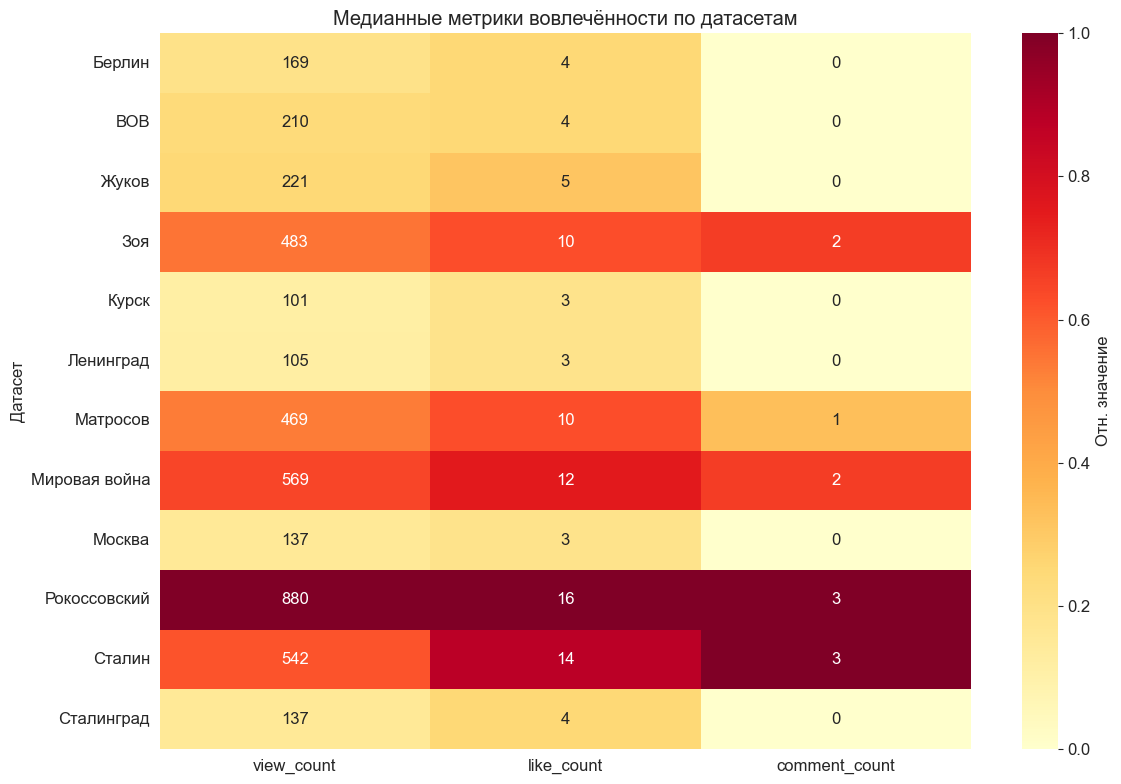

In [74]:
# Engagement metrics by dataset
engagement = (all_videos.groupby('label')[['view_count', 'like_count', 'comment_count']]
              .median().round(0))

fig, ax = plt.subplots(figsize=(12, 8))
# Normalize for heatmap
eng_norm = engagement.div(engagement.max())
sns.heatmap(eng_norm, annot=engagement.astype(int), fmt=',d', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Отн. значение'})
ax.set_title('Медианные метрики вовлечённости по датасетам')
ax.set_ylabel('Датасет')
plt.tight_layout()
plt.show()

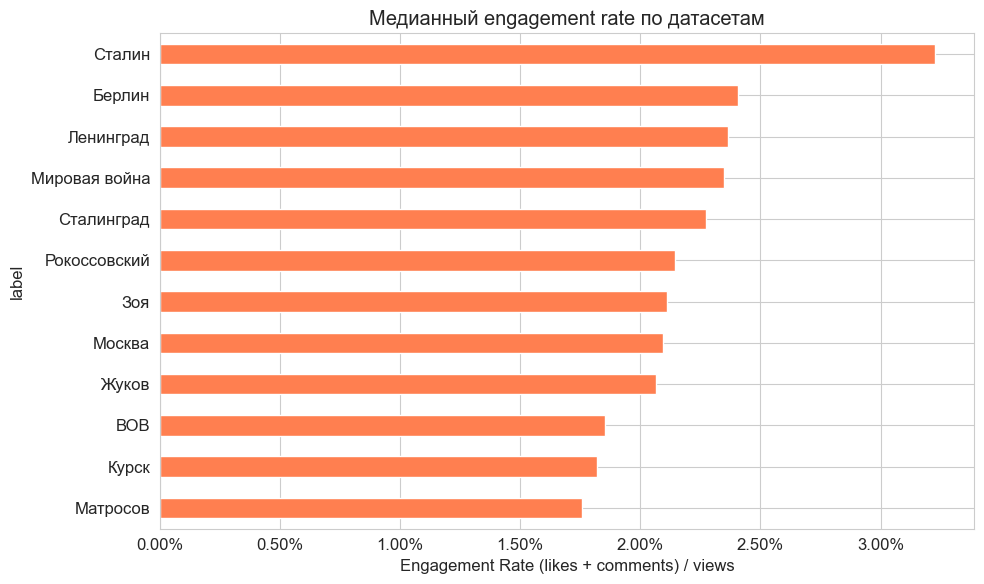

In [75]:
# Engagement rate = (likes + comments) / views
all_videos['engagement_rate'] = ((all_videos['like_count'] + all_videos['comment_count'])
                                  / all_videos['view_count'].replace(0, np.nan))

er_by_ds = all_videos.groupby('label')['engagement_rate'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
er_by_ds.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Медианный engagement rate по датасетам')
ax.set_xlabel('Engagement Rate (likes + comments) / views')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

In [76]:
# Top-10 channels per dataset by video count
for ds_name, ds_info in list(DATASETS.items())[:4]:  # show first 4 as example
    ds_videos = all_videos[all_videos['dataset'] == ds_name]
    top_ch = (ds_videos.groupby('channel_id').size()
              .reset_index(name='video_count_in_ds')
              .nlargest(10, 'video_count_in_ds')
              .merge(channels[['id_channel', 'title_channel', 'subscription_count']],
                     left_on='channel_id', right_on='id_channel', how='left'))
    print(f'\nTop-10 каналов по кол-ву видео — {ds_info["label"]}:')
    display(top_ch[['title_channel', 'video_count_in_ds', 'subscription_count']]
            .rename(columns={'title_channel': 'Канал', 'video_count_in_ds': 'Видео в DS', 'subscription_count': 'Подписчики'})
            .reset_index(drop=True))


Top-10 каналов по кол-ву видео — Берлин:


,Канал,Видео в DS,Подписчики
0,История России,14,4470
1,Para Bellum,9,136000
2,Фронтовая кинолетопись,5,183000
3,Невский Баталист,4,1340
4,За Мир,3,2490
5,Михаил Гуреев,3,22
6,Владимир Пшатов,3,678
7,Дневник коренного крымчанина,3,13700
8,СТРАНИЦЫ ИСТОРИИ,3,1020
9,Натали К (MonStr),3,1



Top-10 каналов по кол-ву видео — Курск:


,Канал,Видео в DS,Подписчики
0,Телерадиокомпания «Сейм»,22,31600
1,Музей Диорама,18,177
2,ТК ТАКТ Курск Новости Курска и Курской области,17,11800
3,МКУК ЦБС г.Курчатова Курской обл.,9,639
4,Канал МПГУ,9,239000
5,Надеюсь вам интерсно..,9,3330
6,Эхо Великой Отечественной,9,2600
7,Канал МПГУ 2,8,5450
8,Центральная библиотека Белгородского района,8,76
9,Роман Свешников,6,592



Top-10 каналов по кол-ву видео — Ленинград:


,Канал,Видео в DS,Подписчики
0,Оренбургская областная библиотека им. Н.К.Круп...,98,894
1,tvsoyuz,45,673000
2,«Утро в Петербурге». Телеканал «Санкт-Петерб...,40,15000
3,БЛОКАДА.ГОЛОСА,36,29500
4,История России,22,4470
5,МКУК Курганинская МЦБС,19,520
6,Узнай Россию: Моё детство - война. Конкурс,18,3200
7,"Студия ""Цвет""",17,2910
8,Пульс города,16,128000
9,ПРО-ТВ,15,2470



Top-10 каналов по кол-ву видео — Москва:


,Канал,Видео в DS,Подписчики
0,Государственный музей обороны Москвы,28,7440
1,История России,13,4470
2,Дмитровское ТВ,13,17200
3,За Мир,10,2490
4,Первый Мытищинский,10,26800
5,"""По следам Великой Войны""",9,14000
6,ВИМ Кремёнки,8,337
7,ИСТОРИЯ.РФ,8,206000
8,Сергей Кирюшкин,8,184
9,История Онлайн,8,139000


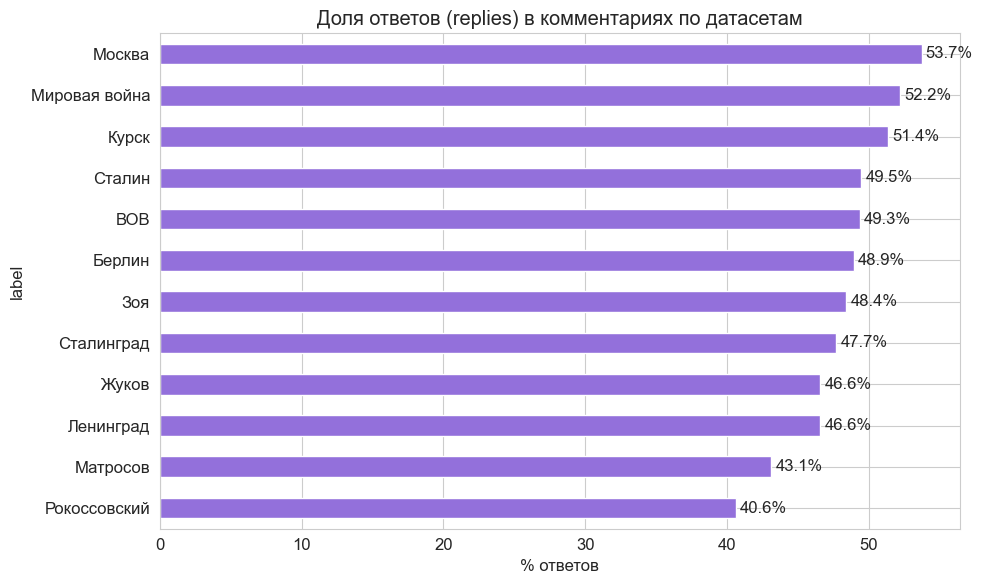

In [77]:
# Comment depth: top-level vs replies
all_comments['is_reply'] = all_comments['parent_comment_id'].notna()

reply_ratio = (all_comments.groupby('label')['is_reply'].mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
reply_ratio.plot(kind='barh', ax=ax, color='mediumpurple')
ax.set_title('Доля ответов (replies) в комментариях по датасетам')
ax.set_xlabel('% ответов')
for i, v in enumerate(reply_ratio.values):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

---
## 7. Репрезентативность данных по каналам

In [78]:
# How much of each channel's content is in our dataset?
channel_video_counts = (all_videos.groupby('channel_id').agg(
    videos_in_data=('video_id', 'nunique'),
    datasets_in=('dataset', 'nunique')
).reset_index())

channel_coverage = channel_video_counts.merge(
    channels[['id_channel', 'title_channel', 'video_count', 'subscription_count', 'history_score', 'history_class']],
    left_on='channel_id', right_on='id_channel', how='left'
)

# Coverage percentage
channel_coverage['coverage_pct'] = (
    channel_coverage['videos_in_data'] / channel_coverage['video_count'].replace(0, np.nan) * 100
)
# Cap at 100% (data might have more unique videos than video_count if channel was updated)
channel_coverage['coverage_pct'] = channel_coverage['coverage_pct'].clip(upper=100)

print(f'Каналов с рассчитанным покрытием: {channel_coverage["coverage_pct"].notna().sum():,}')
print(f'\nСтатистика coverage_pct:')
display(channel_coverage['coverage_pct'].describe().round(2))

Каналов с рассчитанным покрытием: 20,350

Статистика coverage_pct:


count    20350.00
mean         8.59
std         19.78
min          0.00
25%          0.38
50%          1.39
75%          5.88
max        100.00
Name: coverage_pct, dtype: float64

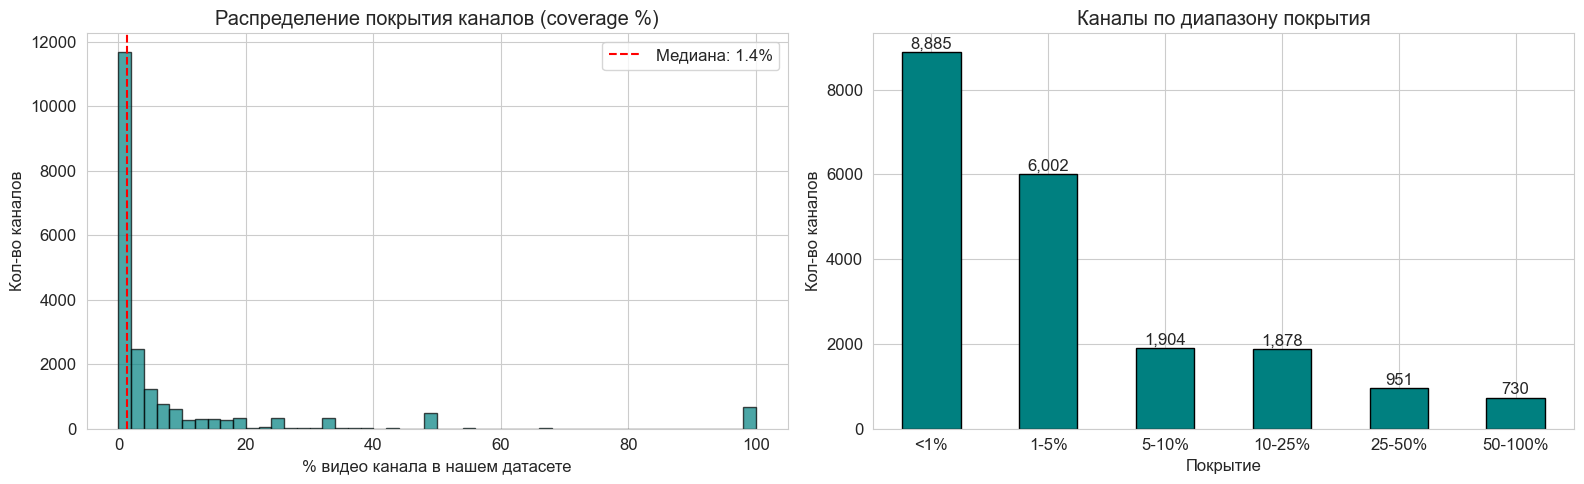

In [79]:
# Distribution of coverage
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
cov_data = channel_coverage['coverage_pct'].dropna()
axes[0].hist(cov_data, bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0].set_title('Распределение покрытия каналов (coverage %)')
axes[0].set_xlabel('% видео канала в нашем датасете')
axes[0].set_ylabel('Кол-во каналов')
axes[0].axvline(cov_data.median(), color='red', linestyle='--', label=f'Медиана: {cov_data.median():.1f}%')
axes[0].legend()

# Bucketed view
bins = [0, 1, 5, 10, 25, 50, 100.01]
labels_cov = ['<1%', '1-5%', '5-10%', '10-25%', '25-50%', '50-100%']
channel_coverage['coverage_bucket'] = pd.cut(channel_coverage['coverage_pct'], bins=bins, labels=labels_cov)
bucket_counts = channel_coverage['coverage_bucket'].value_counts().reindex(labels_cov)
bucket_counts.plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title('Каналы по диапазону покрытия')
axes[1].set_xlabel('Покрытие')
axes[1].set_ylabel('Кол-во каналов')
for i, v in enumerate(bucket_counts.values):
    if not pd.isna(v):
        axes[1].text(i, v + bucket_counts.max()*0.01, f'{int(v):,}', ha='center')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [80]:
# Scatter: coverage vs subscribers
plot_cov = channel_coverage.dropna(subset=['coverage_pct', 'subscription_count'])
plot_cov = plot_cov[plot_cov['subscription_count'] > 0]

fig = px.scatter(plot_cov.sample(min(5000, len(plot_cov)), random_state=42),
                 x='subscription_count', y='coverage_pct',
                 color='history_class',
                 hover_data=['title_channel', 'videos_in_data', 'video_count'],
                 log_x=True,
                 title='Покрытие канала vs Подписчики',
                 labels={'subscription_count': 'Подписчики (log)', 'coverage_pct': 'Coverage %'},
                 color_discrete_map={'Исторический': 'green', 'Смешанный': 'orange', 'Off-topic / Общий': 'red'})
fig.update_layout(height=600)
fig.show()

In [81]:
# Top-20 channels by coverage (niche specialists)
top_coverage = (channel_coverage[channel_coverage['videos_in_data'] >= 5]
                .nlargest(20, 'coverage_pct')
                [['title_channel', 'videos_in_data', 'video_count', 'coverage_pct',
                  'subscription_count', 'history_score']]
                .reset_index(drop=True))
top_coverage.index += 1
top_coverage.columns = ['Канал', 'Видео в DS', 'Всего видео', 'Coverage %', 'Подписчики', 'History Score']
print('Top-20 каналов по покрытию (min 5 видео в датасете):')
display(top_coverage.style.format({'Coverage %': '{:.1f}%', 'Подписчики': '{:,.0f}', 'History Score': '{:.3f}'}))

Top-20 каналов по покрытию (min 5 видео в датасете):


,Канал,Видео в DS,Всего видео,Coverage %,Подписчики,History Score
1,userd2010,7,7.000000,100.0%,4,0.218
2,Pobeda451,25,26.000000,96.2%,6,0.273
3,Герои подарившие мир,14,15.000000,93.3%,10,0.244
4,Михаил Коршунов,14,17.000000,82.4%,16,0.291
5,СТАЛИНГРАДСКАЯ ЭПОПЕЯ,524,641.000000,81.7%,"1,230",0.268
6,Novosibirsk Video History,12,15.000000,80.0%,9,0.257
7,САВАШ,44,57.000000,77.2%,376,0.255
8,Фронтовой дневник,10,13.000000,76.9%,"10,900",0.350
9,tranceradioru,45,60.000000,75.0%,"1,350",0.309
10,Дмитрий Удав Dmitry Udav,9,12.000000,75.0%,209,0.236


In [82]:
# Per-dataset median coverage
coverage_per_ds = []
for ds_name, ds_info in DATASETS.items():
    ds_channels = all_videos[all_videos['dataset'] == ds_name]['channel_id'].unique()
    ds_cov = channel_coverage[channel_coverage['channel_id'].isin(ds_channels)]['coverage_pct']
    coverage_per_ds.append({
        'Dataset': ds_info['label'],
        'Каналов': len(ds_channels),
        'Медианное покрытие %': ds_cov.median(),
        'Среднее покрытие %': ds_cov.mean(),
        '% каналов с coverage > 10%': (ds_cov > 10).mean() * 100
    })

coverage_ds_df = pd.DataFrame(coverage_per_ds)
display(coverage_ds_df.style.format({
    'Медианное покрытие %': '{:.2f}',
    'Среднее покрытие %': '{:.2f}',
    '% каналов с coverage > 10%': '{:.1f}%'
}))

,Dataset,Каналов,Медианное покрытие %,Среднее покрытие %,% каналов с coverage > 10%
0,Берлин,347,2.54,10.68,25.4%
1,Курск,1010,1.75,9.40,20.1%
2,Ленинград,3080,0.95,6.68,13.2%
3,Москва,943,1.52,7.48,18.0%
4,Сталинград,2140,1.41,8.44,18.6%
5,Матросов,105,1.07,13.64,21.9%
6,Рокоссовский,102,1.31,6.36,16.7%
7,Сталин,3624,1.11,6.22,13.0%
8,Жуков,711,1.07,5.38,11.0%
9,Зоя,302,1.09,6.59,14.9%


---
## 8. Формирование пула репрезентативных каналов

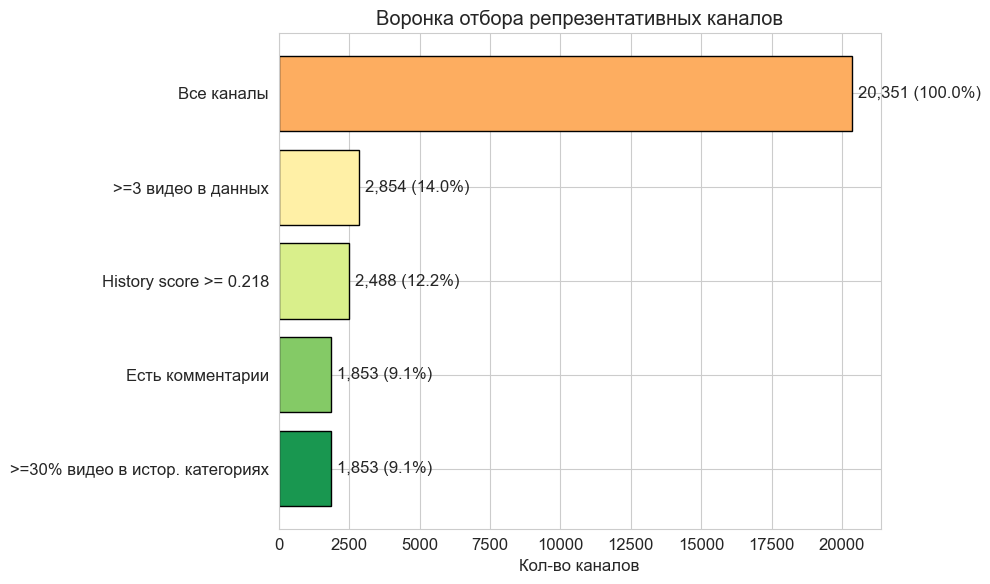


Итого в пуле: 1,853 каналов из 20,351


In [83]:
# Sequential filtering with funnel
total_channels = len(channel_coverage)
funnel = [('Все каналы', total_channels)]

# Filter 1: Minimum presence (>= 3 videos in dataset)
f1 = channel_coverage[channel_coverage['videos_in_data'] >= 3]
funnel.append(('>=3 видео в данных', len(f1)))

# Filter 2: History focus (above median score)
threshold = channels['history_score'].quantile(0.50)
hist_channels = set(channels[channels['history_score'] >= threshold]['id_channel'])
f2 = f1[f1['channel_id'].isin(hist_channels)]
funnel.append((f'History score >= {threshold:.3f}', len(f2)))

# Filter 3: Has comments in data
channels_with_comments = set(all_comments.merge(all_videos[['video_id', 'channel_id']], on='video_id')['channel_id'].unique())
f3 = f2[f2['channel_id'].isin(channels_with_comments)]
funnel.append(('Есть комментарии', len(f3)))

# Filter 4: Relevant YouTube categories (>50% of videos in history-friendly categories)
channel_cat_majority = (all_videos.assign(is_hist_cat=all_videos['category'].isin(history_categories))
                        .groupby('channel_id')['is_hist_cat'].mean())
relevant_cats = set(channel_cat_majority[channel_cat_majority >= 0.3].index)
f4 = f3[f3['channel_id'].isin(relevant_cats)]
funnel.append(('>=30% видео в истор. категориях', len(f4)))

representative_pool = f4.copy()

# Funnel chart
funnel_df = pd.DataFrame(funnel, columns=['Stage', 'Count'])

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(funnel_df)))
bars = ax.barh(range(len(funnel_df)-1, -1, -1), funnel_df['Count'], color=colors, edgecolor='black')
ax.set_yticks(range(len(funnel_df)-1, -1, -1))
ax.set_yticklabels(funnel_df['Stage'])
ax.set_title('Воронка отбора репрезентативных каналов')
ax.set_xlabel('Кол-во каналов')
for i, (bar, count) in enumerate(zip(bars, funnel_df['Count'])):
    ax.text(bar.get_width() + total_channels*0.01, bar.get_y() + bar.get_height()/2,
            f'{count:,} ({count/total_channels*100:.1f}%)', va='center')
plt.tight_layout()
plt.show()

print(f'\nИтого в пуле: {len(representative_pool):,} каналов из {total_channels:,}')

In [84]:
# Comparison: pool vs excluded
pool_ids = set(representative_pool['channel_id'])
channel_coverage['in_pool'] = channel_coverage['channel_id'].isin(pool_ids)

comparison = channel_coverage.groupby('in_pool').agg(
    channels=('channel_id', 'count'),
    median_videos=('videos_in_data', 'median'),
    median_coverage=('coverage_pct', 'median'),
    median_subs=('subscription_count', 'median'),
    total_videos=('videos_in_data', 'sum'),
    median_history_score=('history_score', 'median'),
).round(2)
comparison.index = ['Исключён', 'В пуле']

print('Сравнение: пул vs исключённые каналы')
display(comparison)

Сравнение: пул vs исключённые каналы


,channels,median_videos,median_coverage,median_subs,total_videos,median_history_score
Исключён,18498,1.0,1.39,301.0,26090,0.22
В пуле,1853,5.0,1.25,4780.0,18871,0.25


In [ ]:
pool_video_ids = set(all_videos[all_videos['channel_id'].isin(pool_ids)]['video_id'])
pool_comment_count = all_comments[all_comments['video_id'].isin(pool_video_ids)].shape[0]

print(f'Пул покрывает:')
print(f'  Видео: {len(pool_video_ids):,} из {all_videos["video_id"].nunique():,} '
      f'({len(pool_video_ids)/all_videos["video_id"].nunique()*100:.1f}%)')
print(f'  Комментарии: {pool_comment_count:,} из {len(all_comments):,} '
      f'({pool_comment_count/len(all_comments)*100:.1f}%)')

Пул покрывает:
  Видео: 18,871 из 44,961 (42.0%)
  Комментарии: 3,176,869 из 4,825,616 (65.8%)


### Решение: оставляем все каналы или фильтруем?

In [ ]:
non_hist_categories = set(YT_CATEGORIES.keys()) - history_categories
noise_videos = all_videos[
    all_videos['category'].isin({10, 17, 20})  
]
noise_pct = len(noise_videos) / len(all_videos) * 100

print(f'Явно нерелевантные видео (Music, Sports, Gaming): {len(noise_videos):,} ({noise_pct:.1f}%)')
print(f'\nНерелевантные видео по датасетам:')
noise_by_ds = noise_videos.groupby('label').size().sort_values(ascending=False)
display(noise_by_ds)

print(f'\n--- ВЫВОД ---')
if noise_pct < 10:
    print(f'Уровень шума ({noise_pct:.1f}%) невысок.')
    print(f'Рекомендация: для общего анализа можно работать со всеми каналами.')
    print(f'Для углублённого анализа используйте отфильтрованный пул ({len(representative_pool):,} каналов),')
    print(f'который покрывает основную долю исторического контента.')
else:
    print(f'Уровень шума ({noise_pct:.1f}%) значителен.')
    print(f'Рекомендация: использовать отфильтрованный пул ({len(representative_pool):,} каналов).')
    print(f'Исключённые каналы содержат преимущественно нерелевантный контент.')

Явно нерелевантные видео (Music, Sports, Gaming): 0 (0.0%)

Нерелевантные видео по датасетам:


Series([], dtype: int64)


--- ВЫВОД ---
Уровень шума (0.0%) невысок.
Рекомендация: для общего анализа можно работать со всеми каналами.
Для углублённого анализа используйте отфильтрованный пул (1,853 каналов),
который покрывает основную долю исторического контента.


In [87]:
pool_sample = (representative_pool.nlargest(30, 'subscription_count')
               [['title_channel', 'subscription_count', 'videos_in_data', 'video_count',
                 'coverage_pct', 'history_score']]
               .reset_index(drop=True))
pool_sample.index += 1
pool_sample.columns = ['Канал', 'Подписчики', 'Видео в DS', 'Всего видео', 'Coverage %', 'History Score']
print(f'Top-30 каналов пула по подписчикам:')
display(pool_sample.style.format({
    'Подписчики': '{:,.0f}', 'Coverage %': '{:.1f}%', 'History Score': '{:.3f}'
}))

Top-30 каналов пула по подписчикам:


,Канал,Подписчики,Видео в DS,Всего видео,Coverage %,History Score
1,24 Канал,"8,450,000",15,290436.000000,0.0%,0.263
2,ТСН,"5,610,000",7,282332.000000,0.0%,0.255
3,Телеканал ICTV,"5,230,000",45,43083.000000,0.1%,0.318
4,Телеканал Дождь,"4,790,000",14,27499.000000,0.1%,0.273
5,УНІАН,"4,690,000",3,52198.000000,0.0%,0.241
6,Радио Свобода,"4,430,000",22,28254.000000,0.1%,0.288
7,В гостях у Гордона,"4,410,000",29,25097.000000,0.1%,0.291
8,Настоящее Время,"3,910,000",6,21851.000000,0.0%,0.291
9,Факти ICTV,"3,560,000",21,118952.000000,0.0%,0.291
10,МИНАЕВ LIVE,"3,490,000",20,462.000000,4.3%,0.319


---
## 9. Выводы

### Что есть в данных
- 12 тематических датасетов, охватывающих ключевые события и личности ВОВ
- Временной охват: от первых видео на YouTube до настоящего времени
- Значительное пересечение каналов между датасетами (многие каналы затрагивают несколько тем)
- Богатые метаданные: просмотры, лайки, комментарии, описания, ключевые слова каналов

### Чего не хватает / ограничения
- Не все каналы имеют заполненные поля `country` и `keywords`
- Покрытие каналов неравномерное: для большинства каналов в данных лишь малая доля их контента
- Датасет `matros` содержит заметный шум (нерелевантные видео)
- Дубликаты видео между датасетами требуют дедупликации при объединённом анализе
- Есть опасные каналы!!!